# 06 - Training local agents to tune their volt-var curves

Notebook 05 defined the learning environment on the CIGRE European MV feeder (CIGRE TB 575,
Section 6.2; nine PV units of Wagle et al., 6.44 MW on feeder 1, TR1 at +4.375 %, inverter
kVA = 1.1 Pmpp): every 15 minutes each unit chooses the upper half of its own IEEE 1547-2018
volt-var curve (V3, V4, Q4) from six local observations, all units receive one shared reward,
and a physics safety layer (the fence) corrects any step that would leave 0.95 to 1.05 pu.
Notebooks 04 and 05 also fixed the references: the Category B default curve (B1) holds the
limit all year but absorbs 1040 Mvarh and raises the losses to 395.5 MWh; the lazy curve (B4)
holds it with 294 Mvarh and 387.4 MWh; a per-step OPF that knows the whole feeder needs far
less still.

**The question of this notebook.** Can agents that see only their own bus learn curves that
keep zero violation hours with less reactive effort and lower losses than the default curve,
and how close do they come to the feeder-wide optimum? The answer is measured on the full
year 2023 with the KPIs of `kpi.py` and with the core reward of notebook 05, against the
fixed curves, and on the 32 sampled days of notebook 04 against an OPF whose objective is
the same core reward.

Steps:

1. The learning algorithm: soft actor-critic with one shared actor; hyperparameters; the loop.
2. The training days.
3. The bound: per-step OPF with the reward as objective, on the 32 sampled days.
4. Training, three seeds.
5. Learning curves.
6. What was learned: the curves, their change over the worst day, the resulting voltages.
7. Position: do units further from the substation behave differently?
8. Results on the full year.
9. Results on the sampled days, with the OPF.
10. Save the models, `train_2023.h5` and `train_summary.json`.
11. Closing.

In [1]:
import json, time, os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
import torch
import opendssdirect as dss

import cigre_dss as cd
import simulate as sim
import kpi
import env
import agents
from env import EnvConfig, VoltVarEnv, DEFAULT_ACTION, TIGHT_ACTION, LAZY_ACTION, action_to_curve

T_NB0 = time.perf_counter()
N_THREADS = 2                   # torch CPU threads, fixed for repeatability
torch.set_num_threads(N_THREADS)
TR1_TAP = 4.375
assert sim.TR1_TAP_PCT == TR1_TAP and sim.KVA_RATIO == 1.1
YEAR = 2023
PV_BUSES, PV_KW, PV_KVA, F1 = sim.PV_BUSES, sim.PV_KW, sim.PV_KVA, sim.F1_BUSES
DT_H = sim.DT_H
SPD = int(24 / DT_H)

pv, loads, attrs = sim.load_year("profiles_2023.h5")
sel = json.load(open("selected_days_2023.json"))
base = json.load(open("baselines_2023.json"))
envcfg = json.load(open("env_config.json"))
CFG = EnvConfig.from_dict(envcfg["env"])                  # the training configuration saved by notebook 05
assert CFG.safety_layer and CFG.w_safety == 0.002 and CFG.w_safety_event == 5.0
DAY_WORST, D_WORST = sel["worst_day"], sel["worst_day_index"]
T = len(pv)
h = np.arange(0, 24, DT_H)
i_noon = D_WORST * SPD + SPD // 2
SAMPLE_DAYS = base["sample_days"]                         # the 32 days of notebook 04
steps_sample = np.concatenate([np.arange(d * SPD, (d + 1) * SPD) for d in SAMPLE_DAYS])
mask_sample = np.zeros(T, dtype=bool); mask_sample[steps_sample] = True
os.makedirs("models", exist_ok=True)

# distance of each PV bus from bus 1 along the radial feeder (tie segments open), as in notebook 04
d_json = cd.load_data()
open_seg = {s["line_segment"] for s in d_json["switches"]}
adj = {}
for l in d_json["lines"]:
    if l["segment"] not in open_seg:
        adj.setdefault(l["from_bus"], []).append((l["to_bus"], l["length_km"]))
        adj.setdefault(l["to_bus"], []).append((l["from_bus"], l["length_km"]))
dist = {1: 0.0}; todo = [1]
while todo:
    b = todo.pop()
    for nb_, km in adj.get(b, []):
        if nb_ not in dist:
            dist[nb_] = dist[b] + km; todo.append(nb_)
DIST_KM = np.array([dist[b] for b in PV_BUSES])
JJ = np.argsort(DIST_KM)                                  # unit indices ordered by distance
UNIT_COLORS = plt.cm.viridis((DIST_KM - DIST_KM.min()) / np.ptp(DIST_KM) * 0.92)

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9})
def legend_below(ax, ncol=3, dy=-0.15, **kw):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, dy), ncol=ncol, frameon=False, **kw)
COL = {"default": "black", "lazy": "tab:orange", "tight": "tab:green", "opf": "tab:red", "unity": "0.55"}
SEED_COL = {0: "tab:blue", 1: "tab:purple", 2: "tab:cyan"}

def load_env_run(name):
    """A run of notebook 05 (env_checks_2023.h5) back into an EnvYearResult."""
    with h5py.File("env_checks_2023.h5", "r") as f:
        g = f[name]
        cfg = json.loads(g.attrs["config"]); pv_kw = np.asarray(g.attrs["pv_kw"], dtype=float); st = g["steps"][:]
        extra = {k: g[k][:].astype(float) for k in ("reward", "reward_core", "term_viol", "term_loss", "term_q", "term_curt",
                                                     "term_safety", "safety_dq", "safety_dp", "v_before", "curves")}
        extra["safety_active"] = g["safety_active"][:].astype(bool); extra["safety_solves"] = g["safety_solves"][:]; extra["config"] = cfg
        return env.EnvYearResult(str(g.attrs["label"]), pv.index[st], st, g["v"][:].astype(float), g["p_kw"][:].astype(float),
                                 g["q_kvar"][:].astype(float), g["irr"][:].astype(float), loads["residential"].values[st].astype(float),
                                 loads["commercial_industrial"].values[st].astype(float), g["losses_kw"][:].astype(float),
                                 g["failed"][:].astype(bool), float(g.attrs["runtime_s"]), extra, pv_kw, cfg["kva_ratio"] * pv_kw)

def core_reward_steps(r):
    """Per-step core reward of notebook 05 from the arrays of any run (environment or simulate.run_year)."""
    excess = np.maximum(0.0, np.maximum(r.v - CFG.v_hi, CFG.v_lo - r.v)).sum(axis=1)
    curt = np.maximum(0.0, r.p_avail_kw - r.p_kw).sum(axis=1)
    return -(CFG.w_viol * excess + CFG.w_loss * r.losses_kw + CFG.w_q * np.abs(r.q_kvar).sum(axis=1) + CFG.w_curt * curt)

runs = {"unity": load_env_run("sweep_B0_1.0"), "default": load_env_run("default_off"),
        "tight": load_env_run("tight_off"), "lazy": load_env_run("lazy_off")}      # full-year fixed references of notebook 05
REF = {n: float(core_reward_steps(r).sum()) for n, r in runs.items()}
for n in ("default", "tight", "lazy"):
    assert abs(REF[n] / envcfg["reward_ranking"][n]["core"] - 1) < 1e-4        # same numbers as notebook 05

print("opendssdirect", dss.__version__, "| torch", torch.__version__, f"({torch.get_num_threads()} threads) | numpy", np.__version__, "| pandas", pd.__version__)
print(f"year {attrs['year']}, {T} steps | worst day {DAY_WORST} (index {D_WORST}) | {len(SAMPLE_DAYS)} sampled days, {len(steps_sample)} steps")
print("environment (env_config.json): " + json.dumps({k: getattr(CFG, k) for k in ("pv_scale", "kva_ratio", "safety_layer", "w_viol", "w_loss", "w_q", "w_curt", "w_safety", "w_safety_event")}))
print("full-year core reward of the fixed references (notebook 05): " + ", ".join(f"{n} {v:,.0f}" for n, v in REF.items()))
print("distance from bus 1, km: " + ", ".join(f"bus {PV_BUSES[j]} {DIST_KM[j]:.2f}" for j in JJ))

opendssdirect 0.9.4 | torch 2.14.0+cpu (2 threads) | numpy 2.4.6 | pandas 2.3.3
year 2023, 35040 steps | worst day 2023-07-22 (index 202) | 32 sampled days, 3072 steps
environment (env_config.json): {"pv_scale": 1.0, "kva_ratio": 1.1, "safety_layer": true, "w_viol": 1000.0, "w_loss": 0.01, "w_q": 0.001, "w_curt": 0.05, "w_safety": 0.002, "w_safety_event": 5.0}
full-year core reward of the fixed references (notebook 05): unity -31,328, default -20,147, tight -35,380, lazy -16,836
distance from bus 1, km: bus 3 7.24, bus 4 7.85, bus 5 8.41, bus 8 8.54, bus 9 8.86, bus 10 9.63, bus 6 9.95, bus 11 9.96, bus 7 10.21


## 1. The learning algorithm

**Soft actor-critic** (SAC; Haarnoja et al. 2018) is an off-policy actor-critic method for
continuous actions. It maximises the expected discounted reward plus an entropy bonus,
$\sum_t \gamma^t\,(r_t + \alpha\,\mathcal{H}(\pi(\cdot|s_t)))$, so the policy stays as random
as the reward allows and explores by itself.

- The **actor** is a Gaussian policy $u \sim \mathcal{N}(\mu(s), \sigma(s))$ squashed by
  $a = \tanh(u)$, so every action lies in $[-1, 1]^3$, the action box of notebook 05; the
  log-density carries the $\tanh$ correction.
- Two **critics** $Q_1, Q_2$ are regressed on the soft Bellman target
  $y = r + \gamma\,(\min_k Q_k^{\mathrm{targ}}(s', a') - \alpha \log\pi(a'|s'))$ with
  $a' \sim \pi(\cdot|s')$. The target critics follow the critics by Polyak averaging
  ($\tau$ = 0.005), and taking the minimum of the two curbs overestimation.
- The actor minimises $\alpha \log\pi(a|s) - \min_k Q_k(s, a)$ over reparameterised actions.
- The **temperature** $\alpha$ is tuned automatically so that the policy entropy stays near
  the target $-|\mathcal{A}| = -3$: exploration is wide while the critics know little and
  narrows as they sharpen.
- Every environment step is followed by one gradient step of critics, actor and $\alpha$ on
  a batch from a replay buffer, so each measured step is reused many times. At evaluation
  the policy is deterministic, $a = \tanh(\mu(s))$.

**Parameter sharing.** One actor and one pair of critics serve all nine units. The network
input is the six local observations of notebook 05 (own voltage, P, Q, sin and cos of the
time of day, irradiance) plus a 9-dimensional one-hot unit ID, 15 numbers in all. Each
environment step yields nine transitions, one per unit, all with the same shared reward and
each with the unit's own next observation. Execution is local: a unit computes its
(V3, V4, Q4) from its own observation and its ID; it sees no other unit and no other bus.
The ID is what allows the shared network to give different units different curves.

**Two rewards, two purposes.** The agent is *trained* on the environment reward of notebook
05 *including* the fence charge (0.002 per kvar the fence adds, ten times that per kW it
curtails, and 5 per step on which it acts), so that curves which need the fence are
penalised. *Evaluation and model selection* use the **core reward** (voltage excess x1000,
losses x0.01 per kW, |Q| x0.001 per kvar, curtailment x0.05 per kW; no fence charge), the
quantity on which notebook 05 ranked the fixed curves, so that learned and fixed curves are
compared on the same number.

| hyperparameter | value | | hyperparameter | value |
|---|---|---|---|---|
| networks | MLP 2 x 128, ReLU (actor and both critics) | | replay buffer | 200,000 transitions (ring) |
| optimiser | Adam, learning rate 3e-4 (actor, critics, $\alpha$) | | batch | 256 |
| discount $\gamma$ | 0.99 | | Polyak $\tau$ | 0.005 |
| entropy target | -3 (minus the action dimension), $\alpha_0$ = 0.2 | | log-std clamp | [-5, 2] |
| input | 6 local observations + 9 one-hot = 15 | | action | 3 in [-1, 1], tanh-squashed |
| warm-up | 2,000 uniformly random environment steps | | updates | one gradient step per environment step |
| episode | one day (96 steps) from the training pool | | day boundary | time limit: stored with done = 0 |
| budget | 500 episodes per seed, 3 seeds | | fence | on throughout (training and evaluation) |
| evaluation | full year, deterministic policy, every 50 episodes and before training (11 points) | | model selection | checkpoint with the best full-year core reward |
| implementation | plain PyTorch, CPU, `agents.py` | | threads | `torch.set_num_threads(2)`, seeds set per run |

Day boundaries are time limits, not terminal states: the feeder keeps running at midnight,
so the last transition of a day is stored with done = 0 and the critic bootstraps through
it (Pardo et al. 2018). The figure shows the loop.

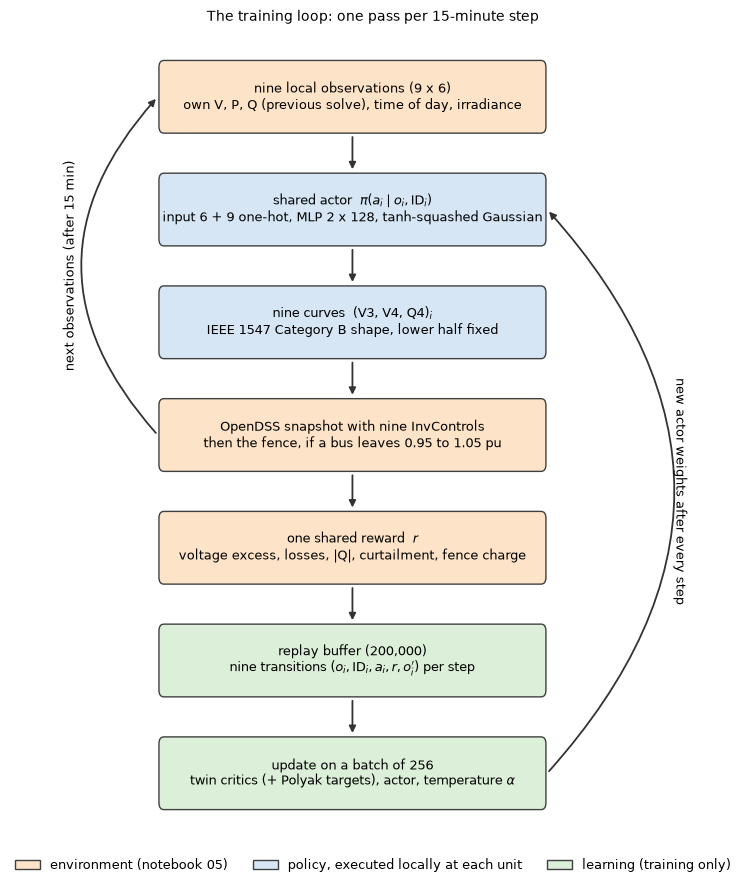

SAC configuration: {"hidden": 128, "n_layers": 2, "lr": 0.0003, "gamma": 0.99, "tau": 0.005, "batch": 256, "buffer": 200000, "target_entropy": -3.0, "alpha_init": 0.2, "n_threads": 2, "seed": 0}
parameters: actor 19,334, twin critics 38,146
budget per seed: 500 episodes = 48,000 environment steps = 432,000 transitions, warm-up 2000 steps, evaluations at episodes [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]; seeds (0, 1, 2)


In [2]:
SAC_CFG = agents.SACConfig(n_threads=N_THREADS)
N_EPISODES, EVAL_EVERY, WARMUP, SEEDS = 500, 50, 2000, (0, 1, 2)
N_TRAIN_DAYS = 120

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_xlim(-2.6, 13.6); ax.set_ylim(-0.4, 14.4); ax.axis("off")
C_ENV, C_AGENT, C_LEARN = "#fde3c8", "#d6e6f5", "#dcefd8"
BOXES = [(13.2, "nine local observations (9 x 6)\nown V, P, Q (previous solve), time of day, irradiance", C_ENV),
         (11.2, "shared actor  $\\pi(a_i \\mid o_i, \\mathrm{ID}_i)$\ninput 6 + 9 one-hot, MLP 2 x 128, tanh-squashed Gaussian", C_AGENT),
         (9.2, "nine curves  (V3, V4, Q4)$_i$\nIEEE 1547 Category B shape, lower half fixed", C_AGENT),
         (7.2, "OpenDSS snapshot with nine InvControls\nthen the fence, if a bus leaves 0.95 to 1.05 pu", C_ENV),
         (5.2, "one shared reward  $r$\nvoltage excess, losses, |Q|, curtailment, fence charge", C_ENV),
         (3.2, "replay buffer (200,000)\nnine transitions $(o_i, \\mathrm{ID}_i, a_i, r, o_i')$ per step", C_LEARN),
         (1.2, "update on a batch of 256\ntwin critics (+ Polyak targets), actor, temperature $\\alpha$", C_LEARN)]
W, H = 9.4, 1.25
for y, text, fc in BOXES:
    ax.add_patch(FancyBboxPatch((5 - W / 2, y - H / 2), W, H, boxstyle="round,pad=0.02,rounding_size=0.12", fc=fc, ec="0.25", lw=1.0))
    ax.text(5, y, text, ha="center", va="center", fontsize=9)
for (y0, _, _), (y1, _, _) in zip(BOXES[:-1], BOXES[1:]):
    ax.annotate("", xy=(5, y1 + H / 2 + 0.04), xytext=(5, y0 - H / 2 - 0.04), arrowprops=dict(arrowstyle="-|>", color="0.2", lw=1.3))
ax.annotate("", xy=(5 - W / 2 - 0.05, 13.2), xytext=(5 - W / 2 - 0.05, 7.2),
            arrowprops=dict(arrowstyle="-|>", color="0.2", lw=1.3, connectionstyle="arc3,rad=-0.45"))
ax.text(-1.9, 10.2, "next observations (after 15 min)", rotation=90, ha="center", va="center", fontsize=9)
ax.annotate("", xy=(5 + W / 2 + 0.05, 11.2), xytext=(5 + W / 2 + 0.05, 1.2),
            arrowprops=dict(arrowstyle="-|>", color="0.2", lw=1.3, connectionstyle="arc3,rad=0.45"))
ax.text(13.0, 6.2, "new actor weights after every step", rotation=270, ha="center", va="center", fontsize=9)
ax.legend(handles=[Patch(fc=C_ENV, ec="0.25", label="environment (notebook 05)"), Patch(fc=C_AGENT, ec="0.25", label="policy, executed locally at each unit"),
                   Patch(fc=C_LEARN, ec="0.25", label="learning (training only)")],
          loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
ax.set_title("The training loop: one pass per 15-minute step")
plt.tight_layout(); plt.show()

n_par = lambda m: sum(p.numel() for p in m.parameters())
_a = agents.SACAgent(SAC_CFG)
print("SAC configuration:", json.dumps(SAC_CFG.to_dict()))
print(f"parameters: actor {n_par(_a.actor):,}, twin critics {n_par(_a.critic):,}")
print(f"budget per seed: {N_EPISODES} episodes = {N_EPISODES * SPD:,} environment steps = {N_EPISODES * SPD * 9:,} transitions, warm-up {WARMUP} steps, "
      f"evaluations at episodes {[0] + list(range(EVAL_EVERY, N_EPISODES + 1, EVAL_EVERY))}; seeds {SEEDS}")

## 2. The training days

An episode is one day (96 steps). The days are drawn from a pool of 120 days sampled once
from the year with seed 0, without replacement, with a weight of 3 for days whose PV peak
(the largest irradiance of any unit on that day) exceeds 0.5 pu and a weight of 1
otherwise: the sunny days carry the voltage problem and therefore the learning signal, but
dull days stay in the pool so that the policy also sees hours in which doing nothing is
right. The remaining 245 days are never seen in training; the evaluation on the full year
therefore measures mostly generalisation. The figure shows (a) the sampled days on the
calendar and (b) the distribution of the PV peak of the sampled days against all days.

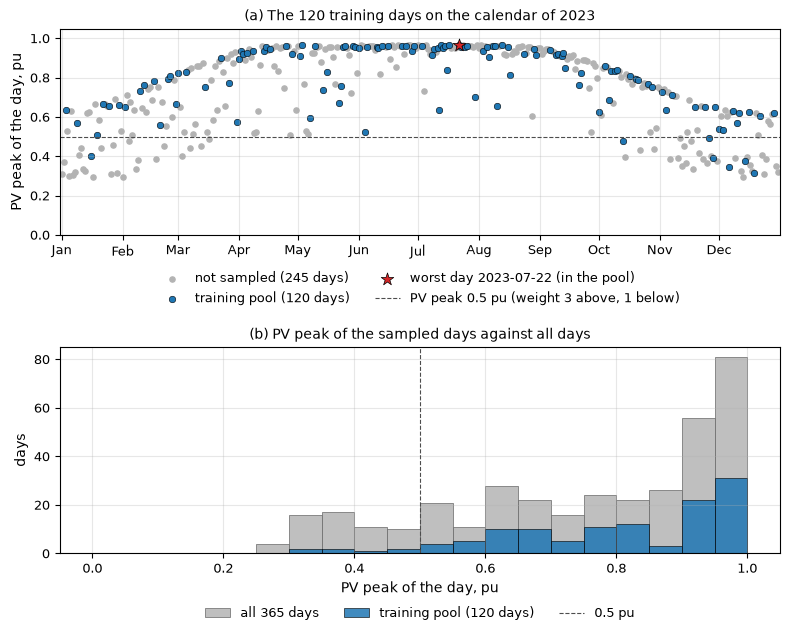

training pool: 120 days, 113 with PV peak > 0.5 pu (94%); year: 307 of 365 (84%)
days per month in the pool: Jan 7, Feb 8, Mar 6, Apr 10, May 12, Jun 11, Jul 15, Aug 12, Sep 8, Oct 12, Nov 8, Dec 11
worst day in the pool: True; sampled days of notebook 04 that are also in the pool: 13 of 32


In [3]:
train_days, day_peaks = agents.sample_training_days(pv, N_TRAIN_DAYS, seed=0, peak_threshold=0.5, weight_sunny=3.0)
in_pool = np.zeros(365, dtype=bool); in_pool[train_days] = True
doy = np.arange(1, 366)
month_start = pd.date_range(f"{YEAR}-01-01", periods=12, freq="MS").dayofyear.values
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5))
ax = axes[0]
ax.scatter(doy[~in_pool], day_peaks[~in_pool], s=14, color="0.7", label=f"not sampled ({(~in_pool).sum()} days)")
ax.scatter(doy[in_pool], day_peaks[in_pool], s=22, color="tab:blue", edgecolor="black", lw=0.4, label=f"training pool ({in_pool.sum()} days)")
ax.scatter([D_WORST + 1], [day_peaks[D_WORST]], s=90, marker="*", color="tab:red", edgecolor="black", lw=0.5, zorder=5,
           label=f"worst day {DAY_WORST} ({'in' if in_pool[D_WORST] else 'not in'} the pool)")
ax.axhline(0.5, color="0.3", lw=0.8, ls="--", label="PV peak 0.5 pu (weight 3 above, 1 below)")
ax.set_xticks(month_start); ax.set_xticklabels(MONTHS); ax.set_xlim(0, 366); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
ax.set_ylabel("PV peak of the day, pu"); ax.set_title(f"(a) The {N_TRAIN_DAYS} training days on the calendar of {YEAR}")
legend_below(ax, ncol=2, dy=-0.12)
ax = axes[1]
bins = np.linspace(0, 1, 21)
ax.hist(day_peaks, bins=bins, color="0.75", edgecolor="0.4", lw=0.5, label="all 365 days")
ax.hist(day_peaks[in_pool], bins=bins, color="tab:blue", edgecolor="black", lw=0.5, alpha=0.85, label=f"training pool ({in_pool.sum()} days)")
ax.axvline(0.5, color="0.3", lw=0.8, ls="--", label="0.5 pu")
ax.set_xlabel("PV peak of the day, pu"); ax.set_ylabel("days"); ax.grid(alpha=0.3)
ax.set_title("(b) PV peak of the sampled days against all days")
legend_below(ax, ncol=3, dy=-0.2)
plt.tight_layout(); plt.show()

n_sunny_all, n_sunny_pool = int((day_peaks > 0.5).sum()), int((day_peaks[in_pool] > 0.5).sum())
per_month = pd.Series(1, index=pd.to_datetime(f"{YEAR}-01-01") + pd.to_timedelta(train_days, unit="D")).resample("MS").sum()
print(f"training pool: {in_pool.sum()} days, {n_sunny_pool} with PV peak > 0.5 pu ({n_sunny_pool / in_pool.sum():.0%}); year: {n_sunny_all} of 365 ({n_sunny_all / 365:.0%})")
print("days per month in the pool: " + ", ".join(f"{m} {int(n)}" for m, n in zip(MONTHS, per_month.values)))
print(f"worst day in the pool: {bool(in_pool[D_WORST])}; sampled days of notebook 04 that are also in the pool: {int(in_pool[SAMPLE_DAYS].sum())} of {len(SAMPLE_DAYS)}")

The pool covers every month. Because most days of this year exceed 0.5 pu at some moment,
the weighting shifts the pool only moderately towards sunny days; its main effect is that
very dull days are rare in training.

## 3. The bound: per-step OPF with the reward as objective

Notebook 04 ran a per-step OPF (B5) that minimises the losses with a small weight on the
reactive power. To measure how far a learned policy is from what is physically possible
*under the reward it is trained and scored on*, the same solver
(`simulate.OPFController`, SLSQP from a warm start with OpenDSS inside the objective) is
run here with `objective="reward"`: it minimises minus the core reward,

$$
J = 1000 \sum_b \max(0,\,V_b - 1.05,\,0.95 - V_b) + 0.01\,P_\mathrm{loss} + 0.001 \sum_i |Q_i| + 0.05\,P_\mathrm{curt},
$$

over the nine reactive setpoints and nine curtailment fractions, with the inverter
capability $Q_i^2 + P_i^2 \le \mathrm{kVA}_i^2$ as a constraint on the available active
power, and $|Q_i| \le 0.44$ kVA as for the curves. It knows every bus voltage and
re-optimises every 15 minutes; it is not a candidate controller but the best that any
controller of these nine inverters could score. It is run on the same 32 sampled days as
B5. The table compares it, on those days, with the default, tight and lazy curves and with
B5; the figure shows the three quantities that matter.

OPF, reward objective (sampled days): 3072 steps in   26.9 s (8.77 ms per step), control-loop failures 0
   8.5 ms per step, power flows per step median 21 (max 3177), constrained solve succeeded on 99.9% of steps, applied candidate {'zero': 2974, 'slsqp': 94, 'warm': 2, 'penalty': 2}, curtailment above 1 kW on 4 steps

the 32 sampled days (3072 steps):
                               core_reward losses_MWh Q_abs_Mvarh Q_inj_Mvarh hours_viol curtailed_MWh    vmax
B1 default curve                    -1,761      33.94        97.1         3.6       0.00        0.0000  1.0421
B3 tight curve                      -3,138      39.16       389.3         3.6       0.00        0.0000  1.0349
B4 lazy curve                       -1,457      33.20        28.7         3.6       0.00        0.0000  1.0485
B5 OPF, loss objective (nb 04)      -1,645      31.72         5.1        88.9       0.00        0.0000  1.0500
OPF, reward objective               -1,338      32.90         4.5         0.4       0.25 

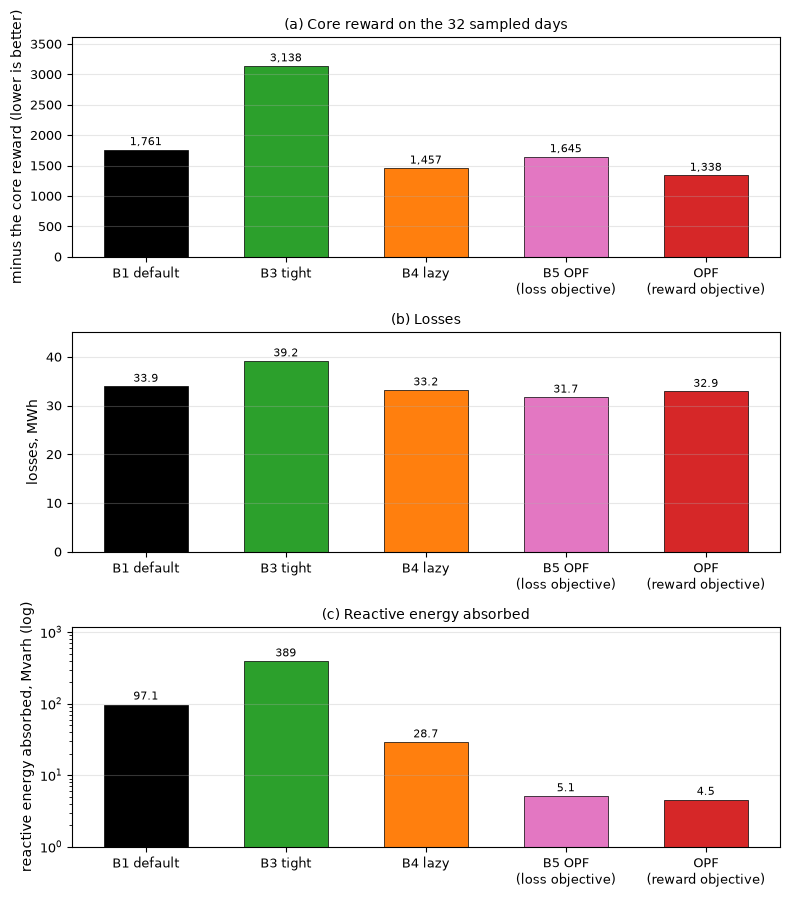

In [4]:
t0 = time.perf_counter()
opf = sim.OPFController(objective="reward", w_viol=CFG.w_viol, w_loss=CFG.w_loss, w_q=CFG.w_q, w_curt=CFG.w_curt,
                        q_max_pu=0.44, curtail=True, capability=True)
runs["opf"] = sim.run_year(opf, steps_sample, pv, loads, label="OPF, reward objective (sampled days)")
opf_log = pd.DataFrame(opf.log)
print(f"   {opf_log.time_s.mean() * 1e3:.1f} ms per step, power flows per step median {opf_log.n_pf.median():.0f} (max {opf_log.n_pf.max()}), "
      f"constrained solve succeeded on {(opf_log.method == 'constrained').mean():.1%} of steps, applied candidate {opf_log.chosen.value_counts().to_dict()}, "
      f"curtailment above 1 kW on {int((opf_log.curtailed_kw > 1.0).sum())} steps")
with h5py.File("baselines_2023.h5", "r") as f:
    g = f["B5"]; st = g["steps"][:]
    runs["B5"] = sim.YearResult("B5 per-step OPF, loss objective (notebook 04)", pv.index[st], st, g["v"][:].astype(float), g["p_kw"][:].astype(float),
                                g["q_kvar"][:].astype(float), g["irr"][:].astype(float), loads["residential"].values[st], loads["commercial_industrial"].values[st],
                                g["losses_kw"][:].astype(float), g["failed"][:].astype(bool), float(g.attrs["runtime_s"]))
assert np.array_equal(runs["B5"].steps, steps_sample)

def row(r, mask=None):
    """KPIs, fence statistics and core reward of a run, optionally on the steps where mask (over the year) is True."""
    m = None if mask is None else mask[r.steps]
    k = kpi.kpis_of(r, m); e = getattr(r, "extra", None) or {}
    sl = slice(None) if m is None else m
    act = e["safety_active"][sl] if "safety_active" in e else np.zeros(1, dtype=bool)
    dq = e["safety_dq"][sl] if "safety_dq" in e else np.zeros(1)
    return dict(hours_viol=k["hours_violation"], vpi_puh=k["vpi"], losses_MWh=k["losses_mwh"], curtailed_MWh=k["curtailed_mwh"],
                Q_abs_Mvarh=k["reactive_absorbed_mvarh"], Q_inj_Mvarh=k["reactive_injected_mvarh"], fence_steps=int(act.sum()),
                fence_kvarh=float(dq.sum() * DT_H), core_reward=float(core_reward_steps(r)[sl].sum()), vmax=k["vmax"])
FMT = {"hours_viol": "{:.2f}", "vpi_puh": "{:.4f}", "losses_MWh": "{:.2f}", "curtailed_MWh": "{:.4f}", "Q_abs_Mvarh": "{:.1f}", "Q_inj_Mvarh": "{:.1f}",
       "fence_steps": "{:.0f}", "fence_kvarh": "{:.0f}", "core_reward": "{:,.0f}", "vmax": "{:.4f}"}
def show(tab):
    out = tab.copy()
    for c in out.columns:
        out[c] = out[c].map(lambda x, f=FMT[c]: f.format(x))
    print(out.to_string())

NAMES = {"unity": "B0 unity pf", "default": "B1 default curve", "tight": "B3 tight curve", "lazy": "B4 lazy curve",
         "B5": "B5 OPF, loss objective (nb 04)", "opf": "OPF, reward objective"}
COLS3 = ["core_reward", "losses_MWh", "Q_abs_Mvarh", "Q_inj_Mvarh", "hours_viol", "curtailed_MWh", "vmax"]
tab3 = pd.DataFrame({NAMES[n]: row(runs[n], mask_sample) for n in ("default", "tight", "lazy", "B5", "opf")}).T[COLS3]
print(f"\nthe {len(SAMPLE_DAYS)} sampled days ({len(steps_sample)} steps):"); show(tab3)
ro = runs["opf"]; over = (ro.v > CFG.v_hi).any(axis=1)
print(f"\nOPF, reward objective: steps above 1.05 pu {int(over.sum())}" + (f" (largest excess {(ro.v.max() - CFG.v_hi):.1e} pu)" if over.any() else "")
      + f", curtailed {row(ro)['curtailed_MWh'] * 1e3:.1f} kWh, absorbs on {int((ro.q_kvar.min(axis=1) < -1).sum())} of {len(ro.steps)} steps; "
      f"runtime {time.perf_counter() - t0:.0f} s")

fig, axes = plt.subplots(3, 1, figsize=(8, 9))
keys = ["default", "tight", "lazy", "B5", "opf"]; x = np.arange(len(keys))
cols = [COL["default"], COL["tight"], COL["lazy"], "tab:pink", COL["opf"]]
for ax, (c, lab, log) in zip(axes, (("core_reward", "minus the core reward (lower is better)", False), ("losses_MWh", "losses, MWh", False),
                                    ("Q_abs_Mvarh", "reactive energy absorbed, Mvarh (log)", True))):
    vals = np.array([abs(tab3.loc[NAMES[k], c]) for k in keys])
    ax.bar(x, vals, 0.6, color=cols, edgecolor="black", lw=0.5)
    for xi, v in zip(x, vals):
        ax.text(xi, v * (1.08 if log else 1.0) + (0 if log else 0.01 * vals.max()), f"{v:,.0f}" if v >= 100 else f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    if log:
        ax.set_yscale("log"); ax.set_ylim(1, vals.max() * 3)
    else:
        ax.set_ylim(0, vals.max() * 1.15)
    ax.set_xticks(x); ax.set_xticklabels(["B1 default", "B3 tight", "B4 lazy", "B5 OPF\n(loss objective)", "OPF\n(reward objective)"])
    ax.set_ylabel(lab); ax.grid(axis="y", alpha=0.3)
axes[0].set_title(f"(a) Core reward on the {len(SAMPLE_DAYS)} sampled days"); axes[1].set_title("(b) Losses"); axes[2].set_title("(c) Reactive energy absorbed")
plt.tight_layout(); plt.show()

On the sampled days the reward-objective OPF scores -1,338, against -1,761 for the default
curve, -1,457 for the lazy curve and -3,138 for the tight curve. It absorbs 4.5 Mvarh where
the default curve absorbs 97.1 and the lazy curve 28.7, and it absorbs on 98 of the 3,072
steps only; its losses, 32.90 MWh, are 0.07 MWh above those of unity power factor. B5 of
notebook 04 has lower losses still (31.72 MWh), but it buys them with 88.9 Mvarh of
injection, much of it at night: its objective prices a kvar at 0.01 kW of losses, whereas the
reward prices it at 0.1 kW (0.001 per kvar against 0.01 per kW). Scored with the reward, B5
reaches only -1,645, below the lazy curve, which is why the bound has to be computed with the
reward's own weights. Two blemishes of the solver are left as they are: one step ends
4 x 10^-6 pu above 1.05 pu (it counts as 0.25 h, with a VPI of 0.0000) and 14 kWh are
curtailed on four steps; both are tolerances of the SLSQP solution and do not move any KPI.

The distance between the default curve and the bound is 423 reward units on these days, and
the single hand-set lazy curve already closes 72 % of it. That is the margin in which a
learned local policy has to show itself.

## 4. Training

Three seeds. For each seed a fresh agent and a fresh environment (`EnvConfig` of
`env_config.json`: 100 % PV, kVA = 1.1 Pmpp, fence on, fence charged) are created with that
seed; the first 2,000 steps use uniformly random actions to fill the buffer, after which the
stochastic policy acts and one gradient update follows every step. Before training and
after every 50 episodes the deterministic policy is run over the full year with the fence
on and scored; the weights of the evaluation with the best full-year core reward are kept
as `models/sac_seed<k>_best.pt`, and the weights at the end as `models/sac_seed<k>_final.pt`.
The cell prints one line per 100 episodes and one line per evaluation.

Seeds are set for torch, for the replay sampling, for the order of the days and for the
warm-up actions, and torch is limited to two CPU threads. On the same machine and library
versions this makes a run repeatable in practice, but floating-point reductions across
threads are not guaranteed bit-identical, and training amplifies any difference, so the
numbers below are those of this execution. Two consecutive executions of this notebook on
the same machine gave identical printed numbers.

In [5]:
def make_eval_fn(E, store, seed):
    def eval_fn(agent, ep):
        r = E.run_policy(agents.sac_policy(agent, deterministic=True), None, label=f"SAC seed {seed}, episode {ep}", verbose=False)
        k = kpi.kpis_of(r); ks = kpi.kpis_of(r, mask_sample); e = r.extra
        out = dict(reward_core=env.reward_core_of(r), reward=float(e["reward"].sum()), fence_charge=float(-e["term_safety"].sum()),
                   reward_core_sample=env.reward_core_of(r, mask_sample), fence_steps=int(e["safety_active"].sum()),
                   fence_kvarh=float(e["safety_dq"].sum() * DT_H), fence_curtailed_kwh=float(e["safety_dp"].sum() * DT_H), eval_time_s=r.runtime_s,
                   **{f"kpi_{c}": k[c] for c in kpi.KPI_COLUMNS}, **{f"kpis_{c}": ks[c] for c in kpi.KPI_COLUMNS})
        store["final_run"] = r
        is_best = store.get("best_value") is None or out["reward_core"] > store["best_value"]      # same rule as agents.train_sac(best_key)
        if is_best:
            store["best_value"], store["best_run"], store["best_episode"] = out["reward_core"], r, ep
        print(f"    evaluation at episode {ep:3d}: core reward {out['reward_core']:9,.0f}  violation {k['hours_violation']:.2f} h  losses {k['losses_mwh']:.1f} MWh  "
              f"Q absorbed {k['reactive_absorbed_mvarh']:4.0f} Mvarh  fence {out['fence_steps']:3d} steps{'  <- best so far' if is_best else ''}")
        return out
    return eval_fn

sac = {}
for seed in SEEDS:
    t0 = time.perf_counter()
    E = VoltVarEnv(EnvConfig.from_dict({**envcfg["env"], "seed": seed}), pv, loads)
    agent = agents.SACAgent(agents.SACConfig(**{**SAC_CFG.to_dict(), "seed": seed}))
    store = {}
    print(f"--- seed {seed} ---")
    log = agents.train_sac(E, agent, train_days, N_EPISODES, warmup=WARMUP, eval_every=EVAL_EVERY, eval_fn=make_eval_fn(E, store, seed),
                           seed=seed, log_every=100, best_key="reward_core")
    assert log["best"]["episode"] == store["best_episode"]
    p_best, p_final = f"models/sac_seed{seed}_best.pt", f"models/sac_seed{seed}_final.pt"
    agents.save_snapshot(log["best"]["snapshot"], p_best); agent.save(p_final)
    log["total_time_s"] = time.perf_counter() - t0
    log["eval_time_s"] = float(sum(e["eval_time_s"] for e in log["evals"]))
    sac[seed] = dict(agent=agent, log=log, best_run=store["best_run"], final_run=store["final_run"], best_episode=int(store["best_episode"]),
                     best_path=p_best, final_path=p_final)
    print(f"    seed {seed}: {log['steps_total']:,} steps, {agent.n_updates:,} updates; training {log['train_time_s'] - log['eval_time_s']:.0f} s + "
          f"evaluations {log['eval_time_s']:.0f} s = {log['total_time_s']:.0f} s; best checkpoint at episode {store['best_episode']} "
          f"(core reward {store['best_value']:,.0f}); saved {p_best}, {p_final}")
print("\ntime per seed: " + "; ".join(f"seed {s}: {v['log']['total_time_s'] / 60:.1f} min" for s, v in sac.items()))

--- seed 0 ---


    evaluation at episode   0: core reward   -18,487  violation 0.00 h  losses 389.4 MWh  Q absorbed  686 Mvarh  fence  26 steps  <- best so far
  episode    1 day 307  reward   -46.26  alpha nan  critic loss      nan  fence  0 steps  (warm-up)  elapsed     25 s


    evaluation at episode  50: core reward   -18,298  violation 0.00 h  losses 388.6 MWh  Q absorbed  647 Mvarh  fence  79 steps  <- best so far


  episode  100 day 298  reward   -45.65  alpha 0.0222  critic loss   1.0682  fence  0 steps    elapsed     99 s


    evaluation at episode 100: core reward   -17,894  violation 0.00 h  losses 387.6 MWh  Q absorbed  556 Mvarh  fence 102 steps  <- best so far


...

  episode  400 day 192  reward   -26.73  alpha 0.0027  critic loss   1.3927  fence  0 steps    elapsed    470 s


    evaluation at episode 400: core reward   -16,695  violation 0.00 h  losses 386.6 MWh  Q absorbed  266 Mvarh  fence  79 steps  <- best so far


    evaluation at episode 450: core reward   -17,166  violation 0.00 h  losses 388.1 MWh  Q absorbed  369 Mvarh  fence  14 steps


  episode  500 day  85  reward   -44.51  alpha 0.0031  critic loss   1.4383  fence  0 steps    elapsed    590 s


    evaluation at episode 500: core reward   -17,034  violation 0.00 h  losses 387.2 MWh  Q absorbed  338 Mvarh  fence  66 steps
    seed 2: 48,000 steps, 46,001 updates; training 326 s + evaluations 291 s = 617 s; best checkpoint at episode 400 (core reward -16,695); saved models/sac_seed2_best.pt, models/sac_seed2_final.pt

time per seed: seed 0: 9.3 min; seed 1: 9.8 min; seed 2: 10.3 min


## 5. Learning curves

The figure shows (a) the reward of the training episodes, including the fence charge, as a
25-episode moving average (the thin lines are the single episodes; their scatter is the
difference between days, not noise of the policy); (b) the full-year core reward of the
deterministic policy at each of the eleven evaluations, with the default and the lazy curve
of notebook 05 as horizontal lines and the kept checkpoint of each seed marked by a star;
(c) the number of steps of the evaluated year on which the fence had to act, on a
logarithmic axis. A second figure gives the internal quantities of the algorithm: the
temperature, the critic loss and the fence interventions per training episode.

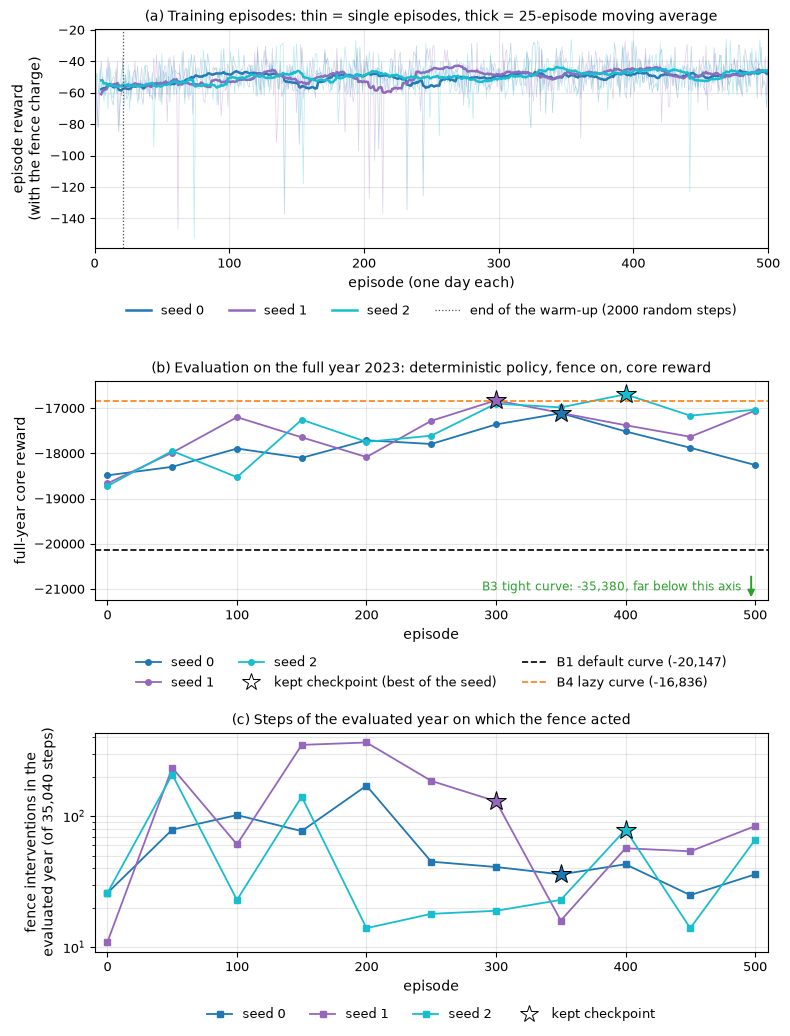

seed 0: core reward at evaluations 0: -18,487, 50: -18,298, 100: -17,894, 150: -18,100, 200: -17,711, 250: -17,793, 300: -17,361, 350: -17,112, 400: -17,514, 450: -17,877, 500: -18,258
        fence steps per evaluated year 26, 79, 102, 77, 171, 45, 41, 36, 43, 25, 36 | best checkpoint: episode 350, final policy -1,146 against the best
        training reward, mean of episodes 51-150: -49.88, of the last 100: -48.47; fence steps per training episode, first 100: 0.08, last 100: 0.18; fence charge per episode, last 100: 0.97; violation hours in training: 0.00
seed 1: core reward at evaluations 0: -18,665, 50: -17,984, 100: -17,200, 150: -17,645, 200: -18,082, 250: -17,280, 300: -16,828, 350: -17,106, 400: -17,377, 450: -17,633, 500: -17,055
        fence steps per evaluated year 11, 234, 61, 350, 365, 186, 130, 16, 57, 54, 84 | best checkpoint: episode 300, final policy -227 against the best
        training reward, mean of episodes 51-150: -51.89, of the last 100: -47.89; fence steps pe

In [6]:
MA = 25
fig, axes = plt.subplots(3, 1, figsize=(8, 10.5))
ax = axes[0]
for s in SEEDS:
    ep = sac[s]["log"]["episodes"]
    ax.plot(ep["episode"], ep["reward"], color=SEED_COL[s], lw=0.5, alpha=0.3)
    ax.plot(ep["episode"], pd.Series(ep["reward"]).rolling(MA, min_periods=5).mean(), color=SEED_COL[s], lw=1.8, label=f"seed {s}")
ax.axvline(WARMUP / SPD, color="0.3", lw=0.9, ls=":", label=f"end of the warm-up ({WARMUP} random steps)")
ax.set_xlim(0, N_EPISODES); ax.grid(alpha=0.3); ax.set_xlabel("episode (one day each)"); ax.set_ylabel("episode reward\n(with the fence charge)")
ax.set_title(f"(a) Training episodes: thin = single episodes, thick = {MA}-episode moving average")
legend_below(ax, ncol=4, dy=-0.2)
ax = axes[1]
allv = [e["reward_core"] for s in SEEDS for e in sac[s]["log"]["evals"]]
for s in SEEDS:
    ev = sac[s]["log"]["evals"]
    ax.plot([e["episode"] for e in ev], [e["reward_core"] for e in ev], "o-", color=SEED_COL[s], lw=1.3, ms=4, label=f"seed {s}")
    eb = next(e for e in ev if e["episode"] == sac[s]["best_episode"])
    ax.plot(eb["episode"], eb["reward_core"], "*", color=SEED_COL[s], ms=15, mec="black", mew=0.7, zorder=5)
ax.plot([], [], "*", color="white", ms=13, mec="black", mew=0.7, label="kept checkpoint (best of the seed)")
ax.axhline(REF["default"], color=COL["default"], lw=1.2, ls="--", label=f"B1 default curve ({REF['default']:,.0f})")
ax.axhline(REF["lazy"], color=COL["lazy"], lw=1.2, ls="--", label=f"B4 lazy curve ({REF['lazy']:,.0f})")
lo_y = min(min(allv), REF["default"]) - 1100; hi_y = max(max(allv), REF["lazy"]) + 300
ax.set_ylim(lo_y, hi_y); ax.set_xlim(-10, N_EPISODES + 10); ax.grid(alpha=0.3)
ax.annotate("", xy=(0.975, 0.0), xytext=(0.975, 0.12), xycoords="axes fraction", arrowprops=dict(arrowstyle="-|>", color=COL["tight"], lw=1.4))
ax.text(0.96, 0.06, f"B3 tight curve: {REF['tight']:,.0f}, far below this axis", transform=ax.transAxes, ha="right", va="center", fontsize=8.5, color=COL["tight"])
ax.set_xlabel("episode"); ax.set_ylabel("full-year core reward")
ax.set_title(f"(b) Evaluation on the full year {YEAR}: deterministic policy, fence on, core reward")
legend_below(ax, ncol=3, dy=-0.2)
ax = axes[2]
for s in SEEDS:
    ev = sac[s]["log"]["evals"]
    ax.plot([e["episode"] for e in ev], [max(e["fence_steps"], 0.5) for e in ev], "s-", color=SEED_COL[s], lw=1.3, ms=4, label=f"seed {s}")
    eb = next(e for e in ev if e["episode"] == sac[s]["best_episode"])
    ax.plot(eb["episode"], max(eb["fence_steps"], 0.5), "*", color=SEED_COL[s], ms=15, mec="black", mew=0.7, zorder=5)
ax.plot([], [], "*", color="white", ms=13, mec="black", mew=0.7, label="kept checkpoint")
ax.set_yscale("log"); ax.set_xlim(-10, N_EPISODES + 10); ax.grid(alpha=0.3, which="both")
ax.set_xlabel("episode"); ax.set_ylabel(f"fence interventions in the\nevaluated year (of {T:,} steps)")
ax.set_title("(c) Steps of the evaluated year on which the fence acted")
legend_below(ax, ncol=4, dy=-0.2)
plt.tight_layout(); plt.show()

for s in SEEDS:
    ev = sac[s]["log"]["evals"]; ep = sac[s]["log"]["episodes"]
    print(f"seed {s}: core reward at evaluations " + ", ".join(f"{e['episode']}: {e['reward_core']:,.0f}" for e in ev))
    print(f"        fence steps per evaluated year " + ", ".join(str(e["fence_steps"]) for e in ev) + f" | best checkpoint: episode {sac[s]['best_episode']}, "
          f"final policy {ev[-1]['reward_core'] - sac[s]['log']['best']['value']:+,.0f} against the best")
    print(f"        training reward, mean of episodes 51-150: {np.mean(ep['reward'][50:150]):.2f}, of the last 100: {np.mean(ep['reward'][-100:]):.2f}; "
          f"fence steps per training episode, first 100: {np.mean(ep['safety_steps'][:100]):.2f}, last 100: {np.mean(ep['safety_steps'][-100:]):.2f}; "
          f"fence charge per episode, last 100: {-np.mean(ep['fence_charge'][-100:]):.2f}; violation hours in training: {np.sum(ep['hours_violation']):.2f}")

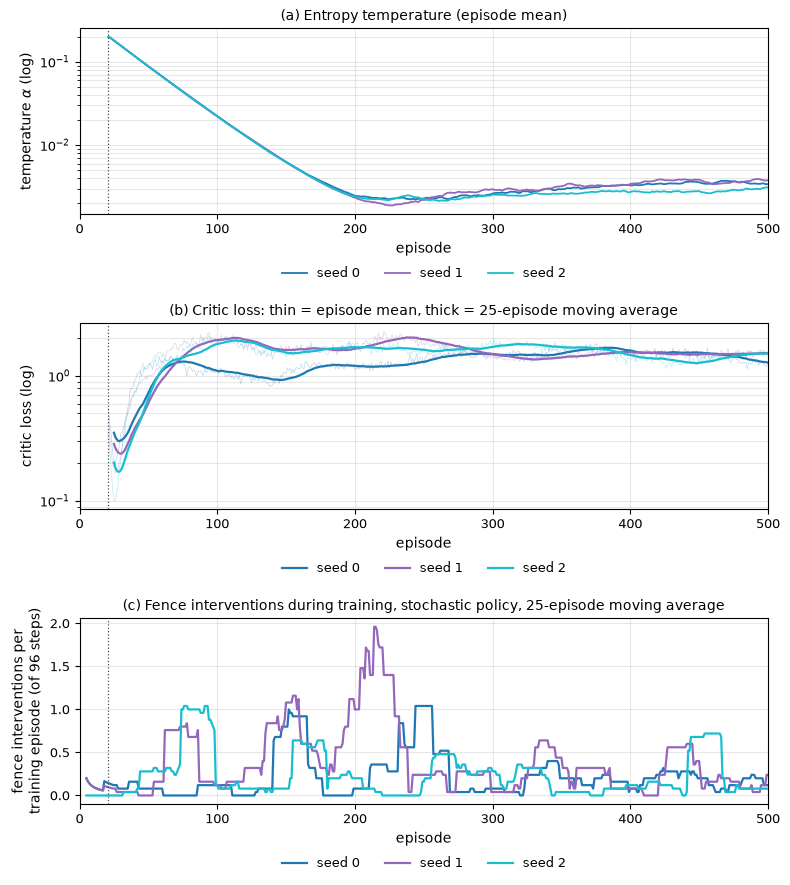

seed 0: alpha at episode 100 0.0222, 200 0.0025, 500 0.0034; critic loss, mean of the last 100 episodes 1.44; policy entropy, last 100: -3.00
seed 1: alpha at episode 100 0.0221, 200 0.0023, 500 0.0038; critic loss, mean of the last 100 episodes 1.50; policy entropy, last 100: -3.01
seed 2: alpha at episode 100 0.0221, 200 0.0024, 500 0.0031; critic loss, mean of the last 100 episodes 1.39; policy entropy, last 100: -3.01


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for s in SEEDS:
    ep = sac[s]["log"]["episodes"]
    axes[0].plot(ep["episode"], ep["alpha"], color=SEED_COL[s], lw=1.3, label=f"seed {s}")
    axes[1].plot(ep["episode"], ep["critic_loss"], color=SEED_COL[s], lw=0.5, alpha=0.3)
    axes[1].plot(ep["episode"], pd.Series(ep["critic_loss"]).rolling(MA, min_periods=5).mean(), color=SEED_COL[s], lw=1.6, label=f"seed {s}")
    axes[2].plot(ep["episode"], pd.Series(ep["safety_steps"]).rolling(MA, min_periods=5).mean(), color=SEED_COL[s], lw=1.6, label=f"seed {s}")
axes[0].set_yscale("log"); axes[0].set_ylabel("temperature $\\alpha$ (log)"); axes[0].set_title("(a) Entropy temperature (episode mean)")
axes[1].set_yscale("log"); axes[1].set_ylabel("critic loss (log)"); axes[1].set_title(f"(b) Critic loss: thin = episode mean, thick = {MA}-episode moving average")
axes[2].set_ylabel("fence interventions per\ntraining episode (of 96 steps)"); axes[2].set_title(f"(c) Fence interventions during training, stochastic policy, {MA}-episode moving average")
for ax in axes:
    ax.axvline(WARMUP / SPD, color="0.3", lw=0.9, ls=":"); ax.set_xlim(0, N_EPISODES); ax.grid(alpha=0.3, which="both"); ax.set_xlabel("episode")
    legend_below(ax, ncol=3, dy=-0.22)
plt.tight_layout(); plt.show()
for s in SEEDS:
    ep = sac[s]["log"]["episodes"]
    print(f"seed {s}: alpha at episode 100 {ep['alpha'][min(99, N_EPISODES - 1)]:.4f}, 200 {ep['alpha'][min(199, N_EPISODES - 1)]:.4f}, {N_EPISODES} {ep['alpha'][-1]:.4f}; critic loss, mean of the last 100 episodes {np.mean(ep['critic_loss'][-100:]):.2f}; "
          f"policy entropy, last 100: {np.mean(ep['entropy'][-100:]):.2f}")

**Training reward.** The episode reward depends strongly on the day (the core reward of a
day lies between about -26 and -77; the deep downward spikes below -80 are the few days
with 5 to 16 fence interventions, each charged at 5 or more), so single episodes scatter widely. The moving
average rises from about -55 during the warm-up to about -50 over episodes 51 to 150 and
-48 over the last 100 episodes (-48.5, -47.9 and -47.5 for the three seeds), and it does
not fall anywhere after the warm-up.

**Full-year evaluation.** The untrained actor (episode 0) already scores -18,487 to
-18,724, better than the default curve's -20,147: a freshly initialised network outputs
actions near zero, i.e. V3 about 1.015, V4 about 1.10 and Q4 about 0.22, a milder default.
Training lifts all three seeds to the level of the lazy curve (-16,836), but not
monotonically: the best evaluations are at episode 350 for seed 0 (-17,112), 300 for seed 1
(-16,828) and 400 for seed 2 (-16,695), and the policies at the end of training score
-18,258, -17,055 and -17,034, which is 1,146, 227 and 340 worse. Since the training reward
does not fall over the same episodes, the drift is not in the objective that is optimised
but in the generalisation from the 120 training days to the 245 days never seen. This is
why the checkpoint is selected on the full-year evaluation. It has a price that must be
kept in mind when reading the tables below: the kept checkpoint is the best of eleven
evaluations on the same year on which it is then reported, so its score is somewhat
favourable; a held-out selection year does not exist in this study.

**Fence.** The untrained policy needs the fence on 11 to 26 steps of the year. During
training the count first rises, up to 365 steps for seed 1 at episode 200, and then falls
again as the fence charge is learned; the kept checkpoints need it on 36, 130 and 79 steps
and the policies at the end on 36, 84 and 66 steps, out of 35,040. In the training episodes
themselves (stochastic policy) the fence acts on 0.18 to 0.26 steps per day over the last
100 episodes and the charge is 1.0 to 1.4 reward units per episode, 2 to 3 % of a day's
reward. No training step ended outside the band (0.00 violation hours in all three logs):
the fence holds the limit while the policy explores.

**Internals.** The temperature falls from 0.2 to 0.022 by episode 100 and to about 0.0025
by episode 200, then creeps up to 0.003 to 0.004: the critics become confident early and
the policy is nearly deterministic for the second half of the training, with the variety
of the days as the remaining source of exploration. The critic loss settles at about 1.4 to
1.5 without any sign of divergence. A plausible reason for this plateau is the event part
of the fence charge, a jump of 5 on rare steps that a local observation can hardly
predict; this was not tested separately.

## 6. What was learned

All of this section uses the kept (best) checkpoint of each seed, run over the full year
with the deterministic policy and the fence on. The first figure shows, one panel per seed,
the curve that each of the nine units applies at 12:00 of the worst day (2023-07-22), as
thin lines coloured by the unit's distance from the substation, over the default (B1) and
the lazy (B4) curve in bold; the shaded band is the range of the nine PV-bus voltages at
that step.

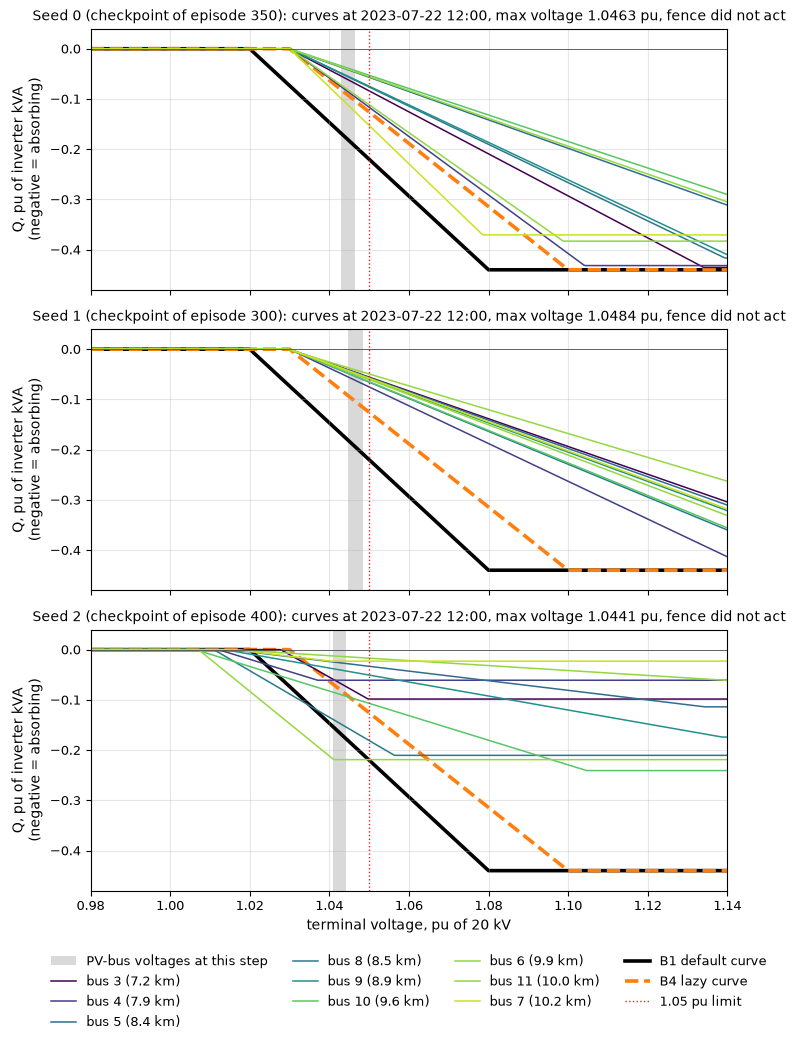

curves at 2023-07-22 12:00:00 (V3, V4, Q4) and the reactive power that results, units ordered by distance:
   unit    km | seed 0: V3     V4     Q4   Q/kVA | seed 1: V3     V4     Q4   Q/kVA | seed 2: V3     V4     Q4   Q/kVA
  bus  3  7.24 |         1.030  1.134  0.435  -0.055 |         1.030  1.179  0.413  -0.041 |         1.028  1.050  0.098  -0.059
  bus  4  7.85 |         1.030  1.104  0.432  -0.078 |         1.030  1.145  0.431  -0.057 |         1.012  1.037  0.061  -0.071
  bus  5  8.41 |         1.030  1.179  0.420  -0.039 |         1.030  1.180  0.423  -0.043 |         1.015  1.134  0.114  -0.025
  bus  8  8.54 |         1.030  1.139  0.417  -0.058 |         1.030  1.156  0.414  -0.056 |         1.011  1.056  0.211  -0.148
  bus  9  8.86 |         1.030  1.148  0.439  -0.058 |         1.030  1.180  0.437  -0.052 |         1.014  1.139  0.174  -0.041
  bus 10  9.63 |         1.030  1.171  0.373  -0.043 |         1.030  1.163  0.430  -0.058 |         1.006  1.105  0.241  -0.091


In [8]:
def at_step(r, step):
    return int(np.where(r.steps == step)[0][0])
def curves_at(r, step):
    return r.extra["curves"][at_step(r, step)]            # (9, 3): V3, V4, Q4

vgrid = np.linspace(0.98, 1.14, 481)
fig, axes = plt.subplots(3, 1, figsize=(8, 10.5), sharex=True)
for ax, s in zip(axes, SEEDS):
    r = sac[s]["best_run"]; k = at_step(r, i_noon); C = r.extra["curves"][k]
    v_pv = r.v[k][[F1.index(b) for b in PV_BUSES]]
    ax.axvspan(v_pv.min(), v_pv.max(), color="0.85", lw=0, label="PV-bus voltages at this step")
    for j in JJ:
        x, y = env.curve_xy(*C[j])
        ax.plot(vgrid, np.interp(vgrid, x, y), color=UNIT_COLORS[j], lw=1.1, label=f"bus {PV_BUSES[j]} ({DIST_KM[j]:.1f} km)")
    for name, a, ls in (("default", DEFAULT_ACTION, "-"), ("lazy", LAZY_ACTION, "--")):
        x, y = env.curve_xy(*action_to_curve(a))
        ax.plot(vgrid, np.interp(vgrid, x, y), color=COL[name], lw=2.6, ls=ls, label=f"{'B1 default' if name == 'default' else 'B4 lazy'} curve", zorder=1)
    ax.axvline(1.05, color="tab:red", lw=1, ls=":", label="1.05 pu limit"); ax.axhline(0, color="0.3", lw=0.6)
    ax.set_xlim(0.98, 1.14); ax.set_ylim(-0.48, 0.04); ax.grid(alpha=0.3)
    ax.set_ylabel("Q, pu of inverter kVA\n(negative = absorbing)")
    ax.set_title(f"Seed {s} (checkpoint of episode {sac[s]['best_episode']}): curves at {pv.index[i_noon]:%Y-%m-%d %H:%M}, "
                 f"max voltage {r.v[k].max():.4f} pu, fence {'acted' if r.extra['safety_active'][k] else 'did not act'}")
axes[-1].set_xlabel("terminal voltage, pu of 20 kV")
legend_below(axes[-1], ncol=4, dy=-0.2)
plt.tight_layout(); plt.show()

print(f"curves at {pv.index[i_noon]} (V3, V4, Q4) and the reactive power that results, units ordered by distance:")
print("   unit    km | " + " | ".join(f"seed {s}: V3     V4     Q4   Q/kVA" for s in SEEDS))
for j in JJ:
    print(f"  bus {PV_BUSES[j]:2d} {DIST_KM[j]:5.2f} | " + " | ".join(
        "        {:.3f}  {:.3f}  {:.3f}  {:+.3f}".format(*curves_at(sac[s]["best_run"], i_noon)[j], sac[s]["best_run"].q_kvar[at_step(sac[s]["best_run"], i_noon), j] / PV_KVA[j]) for s in SEEDS))

A single step says little about a policy that changes its curves every quarter of an hour.
The next figure therefore shows, for the seed with the best full-year core reward, the
three curve parameters of every unit over the 24 hours of the worst day as heatmaps (units
ordered by distance from the substation, nearest at the top); the red marks on the upper
edge are the steps on which the fence acted.

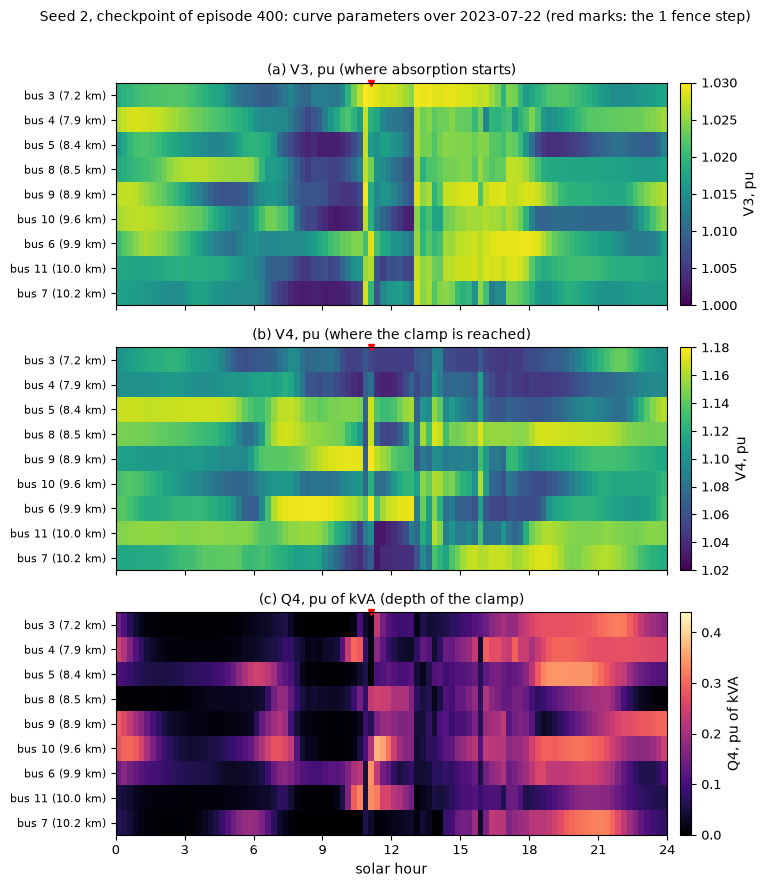

year means of the applied curve parameters (nine units), daylight | night, and the absorption the curve asks for at 1.05 pu:
  seed 0: V3 1.0244 | 1.0198   V4 1.127 | 1.112   Q4 0.250 | 0.193   Q at 1.05 pu 0.069 | 0.071 pu of kVA
  seed 1: V3 1.0226 | 1.0188   V4 1.133 | 1.120   Q4 0.187 | 0.212   Q at 1.05 pu 0.050 | 0.069 pu of kVA
  seed 2: V3 1.0192 | 1.0181   V4 1.106 | 1.117   Q4 0.135 | 0.135   Q at 1.05 pu 0.064 | 0.056 pu of kVA
  reference: default curve asks 0.220, lazy curve 0.126, tight curve 0.440 pu of kVA at 1.05 pu


In [9]:
S_BEST = max(SEEDS, key=lambda s: sac[s]["log"]["best"]["value"])
r = sac[S_BEST]["best_run"]; dm = (r.steps >= D_WORST * SPD) & (r.steps < (D_WORST + 1) * SPD)
Cd = r.extra["curves"][dm]; act_d = r.extra["safety_active"][dm]
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for ax, k, (lab, cmap, vmin, vmax) in zip(axes, range(3), (("V3, pu (where absorption starts)", "viridis", 1.00, 1.03),
                                                          ("V4, pu (where the clamp is reached)", "viridis", 1.02, 1.18),
                                                          ("Q4, pu of kVA (depth of the clamp)", "magma", 0.0, 0.44))):
    im = ax.imshow(Cd[:, JJ, k].T, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, extent=[0, 24, 8.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(9)); ax.set_yticklabels([f"bus {PV_BUSES[j]} ({DIST_KM[j]:.1f} km)" for j in JJ], fontsize=8)
    ax.plot(h[act_d] + DT_H / 2, np.full(act_d.sum(), -0.5), "v", color="red", ms=5, clip_on=False)
    fig.colorbar(im, ax=ax, pad=0.02).set_label(lab.split(" (")[0])
    ax.set_title(f"({'abc'[k]}) {lab}")
axes[-1].set_xticks(range(0, 25, 3)); axes[-1].set_xlabel("solar hour")
fig.suptitle(f"Seed {S_BEST}, checkpoint of episode {sac[S_BEST]['best_episode']}: curve parameters over {DAY_WORST} (red marks: the {int(act_d.sum())} fence step{'s' if act_d.sum() != 1 else ''})", fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

def q_at_limit(C):
    """Absorption that a curve (V3, V4, Q4) asks for at 1.05 pu, pu of kVA."""
    return C[..., 2] * np.clip((1.05 - C[..., 0]) / (C[..., 1] - C[..., 0]), 0.0, 1.0)
daylight = runs["default"].irr.max(axis=1) > 0
print("year means of the applied curve parameters (nine units), daylight | night, and the absorption the curve asks for at 1.05 pu:")
for s in SEEDS:
    C = sac[s]["best_run"].extra["curves"]
    print(f"  seed {s}: V3 {C[daylight, :, 0].mean():.4f} | {C[~daylight, :, 0].mean():.4f}   V4 {C[daylight, :, 1].mean():.3f} | {C[~daylight, :, 1].mean():.3f}   "
          f"Q4 {C[daylight, :, 2].mean():.3f} | {C[~daylight, :, 2].mean():.3f}   Q at 1.05 pu {q_at_limit(C[daylight]).mean():.3f} | {q_at_limit(C[~daylight]).mean():.3f} pu of kVA")
print(f"  reference: default curve asks {q_at_limit(action_to_curve(DEFAULT_ACTION)):.3f}, lazy curve {q_at_limit(action_to_curve(LAZY_ACTION)):.3f}, tight curve {q_at_limit(action_to_curve(TIGHT_ACTION)):.3f} pu of kVA at 1.05 pu")

One number summarises how hard a curve works near the limit: the absorption it asks for at
a terminal voltage of 1.05 pu, $Q_4 \cdot (1.05 - V_3) / (V_4 - V_3)$. The default curve
asks 0.22 pu of kVA there, the lazy curve 0.126, the tight curve 0.44. The figure shows the
distribution of this number over all units and all daylight steps of the year for the
three seeds, and, below it, how it moves over the worst day (mean of the nine units).

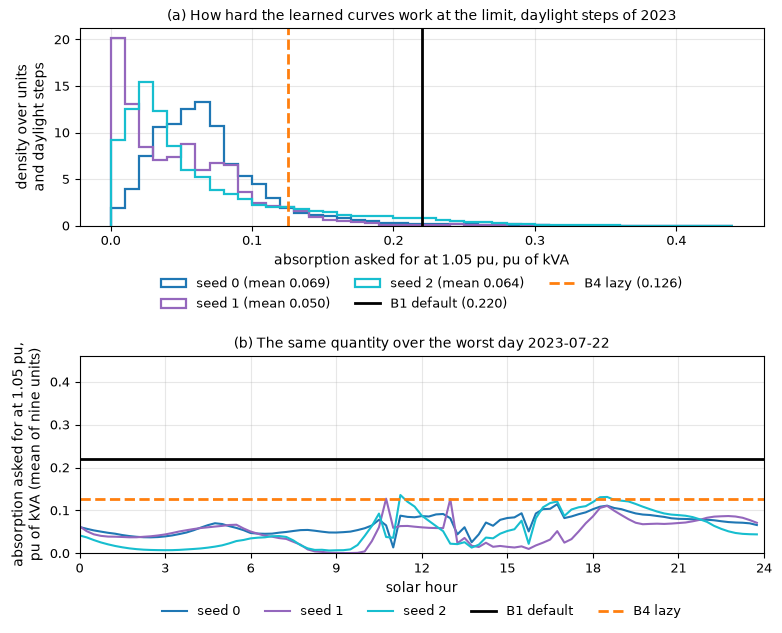

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5))
ax = axes[0]; bins = np.linspace(0, 0.44, 45)
for s in SEEDS:
    qa = q_at_limit(sac[s]["best_run"].extra["curves"][daylight]).ravel()
    ax.hist(qa, bins=bins, histtype="step", color=SEED_COL[s], lw=1.6, density=True, label=f"seed {s} (mean {qa.mean():.3f})")
ax.axvline(0.22, color=COL["default"], lw=2, label="B1 default (0.220)"); ax.axvline(0.44 * 0.02 / 0.07, color=COL["lazy"], lw=2, ls="--", label="B4 lazy (0.126)")
ax.set_xlabel("absorption asked for at 1.05 pu, pu of kVA"); ax.set_ylabel("density over units\nand daylight steps"); ax.grid(alpha=0.3)
ax.set_title(f"(a) How hard the learned curves work at the limit, daylight steps of {YEAR}")
legend_below(ax, ncol=3, dy=-0.2)
ax = axes[1]
for s in SEEDS:
    rr = sac[s]["best_run"]; m = (rr.steps >= D_WORST * SPD) & (rr.steps < (D_WORST + 1) * SPD)
    ax.plot(h, q_at_limit(rr.extra["curves"][m]).mean(axis=1), color=SEED_COL[s], lw=1.5, label=f"seed {s}")
ax.axhline(0.22, color=COL["default"], lw=2, label="B1 default"); ax.axhline(0.44 * 0.02 / 0.07, color=COL["lazy"], lw=2, ls="--", label="B4 lazy")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0, 0.46); ax.grid(alpha=0.3)
ax.set_xlabel("solar hour"); ax.set_ylabel("absorption asked for at 1.05 pu,\npu of kVA (mean of nine units)")
ax.set_title(f"(b) The same quantity over the worst day {DAY_WORST}")
legend_below(ax, ncol=5, dy=-0.2)
plt.tight_layout(); plt.show()

What the curves do to the feeder on the worst day: (a) the voltage of bus 11, the far end of
the long branch, for the default curve, the lazy curve, the three learned policies and the
OPF of step 3; (b) the total reactive power absorbed by the nine units for the same six
controllers.

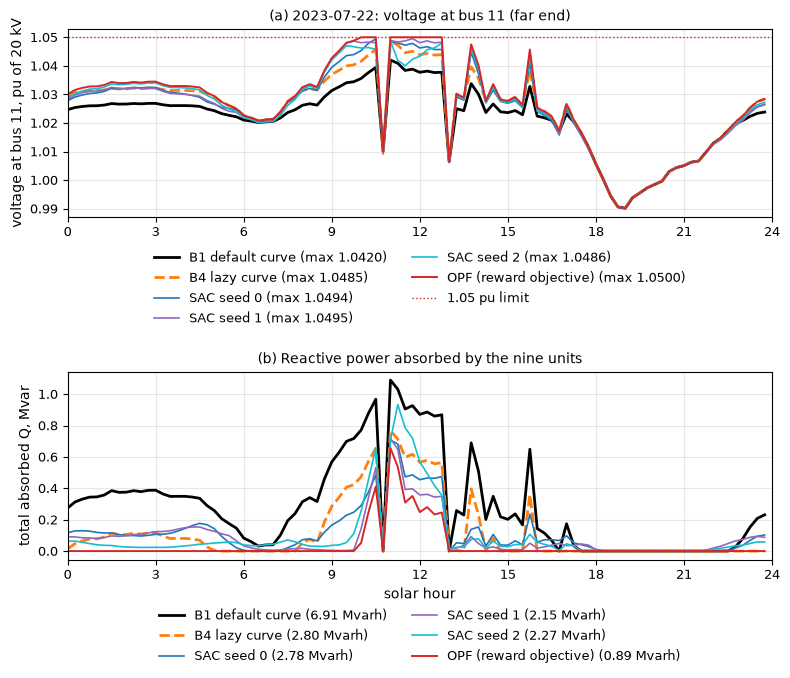

  B1 default curve         worst day: max feeder-1 voltage 1.0421 pu, absorbed   6.91 Mvarh, losses 0.961 MWh, fence steps 0
  B4 lazy curve            worst day: max feeder-1 voltage 1.0485 pu, absorbed   2.80 Mvarh, losses 0.908 MWh, fence steps 0
  SAC seed 0               worst day: max feeder-1 voltage 1.0495 pu, absorbed   2.78 Mvarh, losses 0.899 MWh, fence steps 2
  SAC seed 1               worst day: max feeder-1 voltage 1.0497 pu, absorbed   2.15 Mvarh, losses 0.890 MWh, fence steps 5
  SAC seed 2               worst day: max feeder-1 voltage 1.0490 pu, absorbed   2.27 Mvarh, losses 0.901 MWh, fence steps 1
  OPF (reward objective)   worst day: max feeder-1 voltage 1.0500 pu, absorbed   0.89 Mvarh, losses 0.882 MWh, fence steps 0


In [11]:
j11 = F1.index(11)
def day_of(r):
    m = (r.steps >= D_WORST * SPD) & (r.steps < (D_WORST + 1) * SPD)
    return r.v[m], r.q_kvar[m]
series = [("B1 default curve", runs["default"], COL["default"], "-", 2.0), ("B4 lazy curve", runs["lazy"], COL["lazy"], "--", 2.0)] + \
         [(f"SAC seed {s}", sac[s]["best_run"], SEED_COL[s], "-", 1.2) for s in SEEDS] + [("OPF (reward objective)", runs["opf"], COL["opf"], "-", 1.4)]
fig, axes = plt.subplots(2, 1, figsize=(8, 7))
for lab, r, col, ls, lw in series:
    v, q = day_of(r); qabs = -np.minimum(q, 0).sum(axis=1) / 1e3
    axes[0].plot(h, v[:, j11], color=col, ls=ls, lw=lw, label=f"{lab} (max {v[:, j11].max():.4f})")
    axes[1].plot(h, qabs, color=col, ls=ls, lw=lw, label=f"{lab} ({qabs.sum() * DT_H:.2f} Mvarh)")
axes[0].axhline(1.05, color="tab:red", lw=1, ls=":", label="1.05 pu limit")
axes[0].set_ylabel("voltage at bus 11, pu of 20 kV"); axes[0].set_title(f"(a) {DAY_WORST}: voltage at bus 11 (far end)")
axes[1].set_ylabel("total absorbed Q, Mvar"); axes[1].set_title("(b) Reactive power absorbed by the nine units"); axes[1].set_xlabel("solar hour")
for ax in axes:
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.grid(alpha=0.3)
legend_below(axes[0], ncol=2, dy=-0.12); legend_below(axes[1], ncol=2, dy=-0.2)
plt.tight_layout(); plt.show()
for lab, r, *_ in series:
    m = (r.steps >= D_WORST * SPD) & (r.steps < (D_WORST + 1) * SPD); e = getattr(r, "extra", None) or {}
    print(f"  {lab:24s} worst day: max feeder-1 voltage {r.v[m].max():.4f} pu, absorbed {-np.minimum(r.q_kvar[m], 0).sum() * DT_H / 1e3:6.2f} Mvarh, "
          f"losses {r.losses_kw[m].sum() * DT_H / 1e3:.3f} MWh, fence steps {int(e['safety_active'][m].sum()) if 'safety_active' in e else 0}")

**At the noon of the worst day** two kinds of solution appear. Seeds 0 and 1 put V3 at its
upper bound of 1.030 pu at all nine units (the latest start the standard allows, as in the
lazy curve) with a deep clamp (Q4 0.36 to 0.44) far away (V4 between 1.08 and 1.18), which
gives a slope at or below that of the lazy curve; the units absorb 0.04 to 0.125 pu of their
kVA, 455 and 358 kvar in total, against 871 kvar under the default curve and 248 kvar for the
OPF. Seed 2 does the opposite: early starts (V3 between 1.006 and 1.028), shallow clamps
(Q4 between 0.02 and 0.24) and, at four units, a nearly vertical segment (V4 only 0.02 to
0.035 above V3), so that those units sit on their clamp; bus 11 alone absorbs 0.23 pu of its
kVA and the total is 568 kvar. In all three cases the highest voltage stays at 1.044 to
1.048 pu without the fence at that step.

**Over the day** the parameters move (heatmaps, seed 2): the clamp depth is close to zero
at most units between about 06:00 and 10:00, rises at the units that matter around midday and again
in the evening, and V3 drops at several units in the hours before noon. The policy has
therefore learned a schedule as well as a shape, which a fixed curve cannot have. It is not
a clean schedule: all seeds still absorb at night (0.03 to 0.17 Mvar in the first hours of
the worst day, about the level of the lazy curve and well below the 0.35 Mvar of the
default), when no limit is near and the absorption buys nothing.

**How hard the curves work.** Averaged over the daylight steps of the year the learned
curves ask for 0.069, 0.050 and 0.064 pu of kVA at 1.05 pu, against 0.220 for the default
and 0.126 for the lazy curve (mean V3 1.024, 1.023 and 1.019; mean Q4 0.25, 0.19 and 0.135).
They are milder than the default at almost every step and, on average, milder than the lazy
curve too; on the worst day they rise towards the lazy level only around midday. Their
annual absorption is nevertheless close to that of the lazy curve, because they start
about 0.01 pu earlier and so absorb a little over many more hours. The
remaining risk is carried by the fence on the 36 to 130 steps of the year reported above.

**On the worst day** the three policies keep bus 11 at no more than 1.0494, 1.0495 and
1.0486 pu (lazy curve 1.0485, default 1.0420, OPF 1.0500), absorb 2.78, 2.15 and 2.27 Mvarh
(default 6.91, lazy 2.80, OPF 0.89) and have losses of 0.899, 0.890 and 0.901 MWh (default
0.961, lazy 0.908, OPF 0.882); the fence acted on 2, 5 and 1 steps of that day.

## 7. Position

Notebook 04 showed where the OPF puts its absorption at the noon of the worst day: almost
all of it at the far ends of the feeder (buses 10, 11 and 7), where a kvar moves the
binding bus most. A local agent could in principle imitate this through its unit ID. The
figure shows (a) the reactive power of each unit at 12:00 of the worst day, in pu of its
kVA, with the units ordered by their distance from the substation, for the default curve,
the OPF and the three learned policies; (b) the clamp depth Q4 chosen by each unit at that
step against the distance, per seed, with the Spearman rank correlation $\rho$ in the
legend. The table adds the same correlation for year-long quantities, which do not hinge on
a single step: the mean Q4 over the daylight steps and the reactive energy absorbed per kVA
over the year.

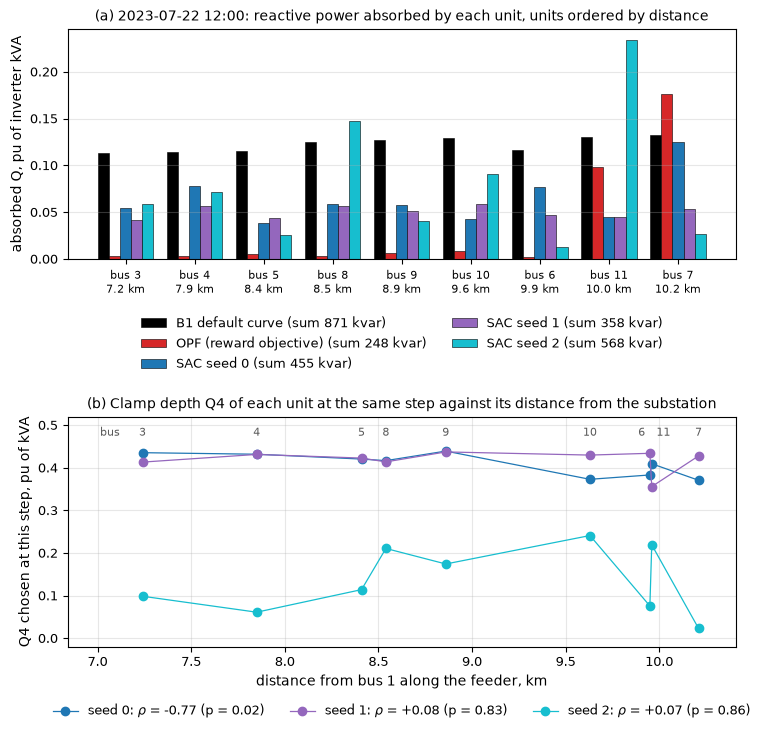

Spearman rank correlation with the distance from the substation (positive = more at the far end), nine units:
                                     rho seed 0  rho seed 1  rho seed 2  p seed 0  p seed 1  p seed 2  mean pairwise rho between seeds
quantity                                                                                                                              
Q4 at worst-day noon                      -0.77       +0.08       +0.07     +0.02     +0.83     +0.86                            -0.07
absorbed Q at worst-day noon              +0.22       +0.18       -0.03     +0.58     +0.64     +0.93                            +0.16
mean Q4, daylight steps of the year       -0.37       -0.48       -0.25     +0.33     +0.19     +0.52                            +0.14
absorbed energy per kVA, year             -0.53       -0.43       -0.18     +0.14     +0.24     +0.64                            +0.21
for reference, absorbed Q at worst-day noon: OPF rho = +0.57, default curve rho 

In [12]:
k_def = at_step(runs["default"], i_noon); k_opf = at_step(runs["opf"], i_noon)
bars = [("B1 default curve", -runs["default"].q_kvar[k_def] / PV_KVA, COL["default"]), ("OPF (reward objective)", -runs["opf"].q_kvar[k_opf] / PV_KVA, COL["opf"])] + \
       [(f"SAC seed {s}", -sac[s]["best_run"].q_kvar[at_step(sac[s]["best_run"], i_noon)] / PV_KVA, SEED_COL[s]) for s in SEEDS]
pos = {}
for s in SEEDS:
    r = sac[s]["best_run"]; C = r.extra["curves"]
    pos[s] = dict(q4_noon=curves_at(r, i_noon)[:, 2], qabs_noon=-r.q_kvar[at_step(r, i_noon)] / PV_KVA,
                  q4_daylight=C[daylight, :, 2].mean(axis=0), qabs_year=-np.minimum(r.q_kvar, 0).sum(axis=0) * DT_H / PV_KVA)

fig, axes = plt.subplots(2, 1, figsize=(8, 7.5))
ax = axes[0]; x = np.arange(9); w = 0.16
for i, (lab, q, col) in enumerate(bars):
    ax.bar(x + (i - 2) * w, np.maximum(q[JJ], 0), w, color=col, edgecolor="black", lw=0.4, label=f"{lab} (sum {q @ PV_KVA:.0f} kvar)")
ax.set_xticks(x); ax.set_xticklabels([f"bus {PV_BUSES[j]}\n{DIST_KM[j]:.1f} km" for j in JJ], fontsize=8)
ax.set_ylabel("absorbed Q, pu of inverter kVA"); ax.grid(axis="y", alpha=0.3)
ax.set_title(f"(a) {pv.index[i_noon]:%Y-%m-%d %H:%M}: reactive power absorbed by each unit, units ordered by distance")
legend_below(ax, ncol=2, dy=-0.2)
ax = axes[1]
for s in SEEDS:
    rho, p = spearmanr(DIST_KM, pos[s]["q4_noon"])
    ax.plot(DIST_KM[JJ], pos[s]["q4_noon"][JJ], "o-", color=SEED_COL[s], lw=0.9, ms=6, label=f"seed {s}: $\\rho$ = {rho:+.2f} (p = {p:.2f})")
for n_, j in enumerate(JJ):                                # bus numbers above the points; two units 10 m apart share one label position
    near_next = n_ + 1 < 9 and DIST_KM[JJ[n_ + 1]] - DIST_KM[j] < 0.06; near_prev = n_ > 0 and DIST_KM[j] - DIST_KM[JJ[n_ - 1]] < 0.06
    ax.text(DIST_KM[j] + (-0.025 if near_next else 0.025 if near_prev else 0.0), 0.475, str(PV_BUSES[j]),
            ha="right" if near_next else "left" if near_prev else "center", fontsize=8, color="0.35")
ax.text(DIST_KM.min() - 0.12, 0.475, "bus", ha="right", fontsize=8, color="0.35")
ax.set_ylim(-0.02, 0.52); ax.set_xlim(DIST_KM.min() - 0.4, DIST_KM.max() + 0.2); ax.grid(alpha=0.3)
ax.set_xlabel("distance from bus 1 along the feeder, km"); ax.set_ylabel("Q4 chosen at this step, pu of kVA")
ax.set_title("(b) Clamp depth Q4 of each unit at the same step against its distance from the substation")
legend_below(ax, ncol=3, dy=-0.2)
plt.tight_layout(); plt.show()

METRICS = {"q4_noon": "Q4 at worst-day noon", "qabs_noon": "absorbed Q at worst-day noon", "q4_daylight": "mean Q4, daylight steps of the year", "qabs_year": "absorbed energy per kVA, year"}
rows = []
for mkey, mlab in METRICS.items():
    rr = {f"rho seed {s}": spearmanr(DIST_KM, pos[s][mkey])[0] for s in SEEDS}
    pp = {f"p seed {s}": spearmanr(DIST_KM, pos[s][mkey])[1] for s in SEEDS}
    pair = [spearmanr(pos[a][mkey], pos[b][mkey])[0] for a in SEEDS for b in SEEDS if a < b]
    rows.append({"quantity": mlab, **rr, **pp, "mean pairwise rho between seeds": float(np.mean(pair))})
pos_tab = pd.DataFrame(rows).set_index("quantity")
print("Spearman rank correlation with the distance from the substation (positive = more at the far end), nine units:")
print(pos_tab.to_string(float_format=lambda v: f"{v:+.2f}"))
rho_opf = spearmanr(DIST_KM, -runs["opf"].q_kvar[k_opf])[0]; rho_def = spearmanr(DIST_KM, -runs["default"].q_kvar[k_def] / PV_KVA)[0]
print(f"for reference, absorbed Q at worst-day noon: OPF rho = {rho_opf:+.2f}, default curve rho = {rho_def:+.2f}; "
      f"share of the OPF's absorption at buses 7, 10, 11: {runs['opf'].q_kvar[k_opf][[PV_BUSES.index(b) for b in (7, 10, 11)]].sum() / runs['opf'].q_kvar[k_opf].sum():.0%}")
signs = [np.sign(pos_tab.loc[METRICS['q4_noon'], f'rho seed {s}']) for s in SEEDS]
print(f"Q4 at worst-day noon: sign of rho per seed {[int(x) for x in signs]}; significant at 5 % in {int(sum(pos_tab.loc[METRICS['q4_noon'], f'p seed {s}'] < 0.05 for s in SEEDS))} of {len(SEEDS)} seeds")

**At the noon of the worst day** the rank correlation between a unit's distance from the
substation and the clamp depth Q4 it chooses is -0.77 (p = 0.02) for seed 0 and +0.08 and
+0.07 (p above 0.8) for seeds 1 and 2; the mean pairwise rank correlation between the three
seeds' Q4 vectors is -0.07. The one significant value has the opposite sign of the OPF's
placement (shallower clamps further out), and it ranks differences of a few hundredths
between clamps that are all between 0.37 and 0.44. For the reactive power actually absorbed
at that step the correlations are +0.22, +0.18 and -0.03, none significant, against +0.57
for the OPF, which places 93 % of its absorption at buses 7, 10 and 11, and +0.90 for the
default curve: any local curve shows a mild far-end pattern for free, because the voltage
it responds to rises along the feeder.

**Over the year** the correlations of the daylight-mean Q4 with distance are -0.37, -0.48
and -0.25, and those of the absorbed energy per kVA -0.53, -0.43 and -0.18. The sign is the
same in the three seeds, but none of the six values is significant with nine units (p
between 0.14 and 0.64), and the seeds do not agree on which units absorb more (mean
pairwise correlation +0.14 and +0.21).

Stated plainly: no position pattern that is consistent across the three seeds was learned.
The units do use their ID, since their curves differ from each other within every seed, but
the differences do not repeat from seed to seed and do not resemble the OPF's allocation;
the only common tendency is weak and points the other way.

## 8. Results on the full year

The table lists, for the full year 2023, the unity-power-factor reference (B0), the three
fixed curves (from notebook 05), the kept checkpoint of each seed, and the mean and the
range of the three seeds: hours outside the band, the violation index VPI, losses,
curtailed energy, reactive energy absorbed and injected, the number of steps on which the
fence acted and the reactive energy it added, and the core reward. A second, shorter table
gives the same for the policies at the end of training. The figure shows losses, absorbed
reactive energy and core reward for the default curve, the lazy curve and each seed.

full year 2023 (35,040 steps); SAC = kept checkpoint of each seed, deterministic policy, fence on:


                         hours_viol vpi_puh losses_MWh curtailed_MWh Q_abs_Mvarh Q_inj_Mvarh fence_steps fence_kvarh core_reward
B0 unity pf                  199.75  3.9947     383.74        0.0001         0.0         0.0           0           0     -31,328
B1 default curve               0.00  0.0000     395.52        0.0001      1040.4        41.1           0           0     -20,147
B3 tight curve                 0.00  0.0000     453.15        0.0001      4272.4        41.1           0           0     -35,380
B4 lazy curve                  0.00  0.0000     387.41        0.0001       293.7        41.1           0           0     -16,836
SAC seed 0 (episode 350)       0.00  0.0000     386.44        0.0000       372.4        41.1          36        1347     -17,112
SAC seed 1 (episode 300)       0.00  0.0000     385.60        0.0000       309.8        41.1         130        4167     -16,828
SAC seed 2 (episode 400)       0.00  0.0000     386.63        0.0048       266.0        41.1    

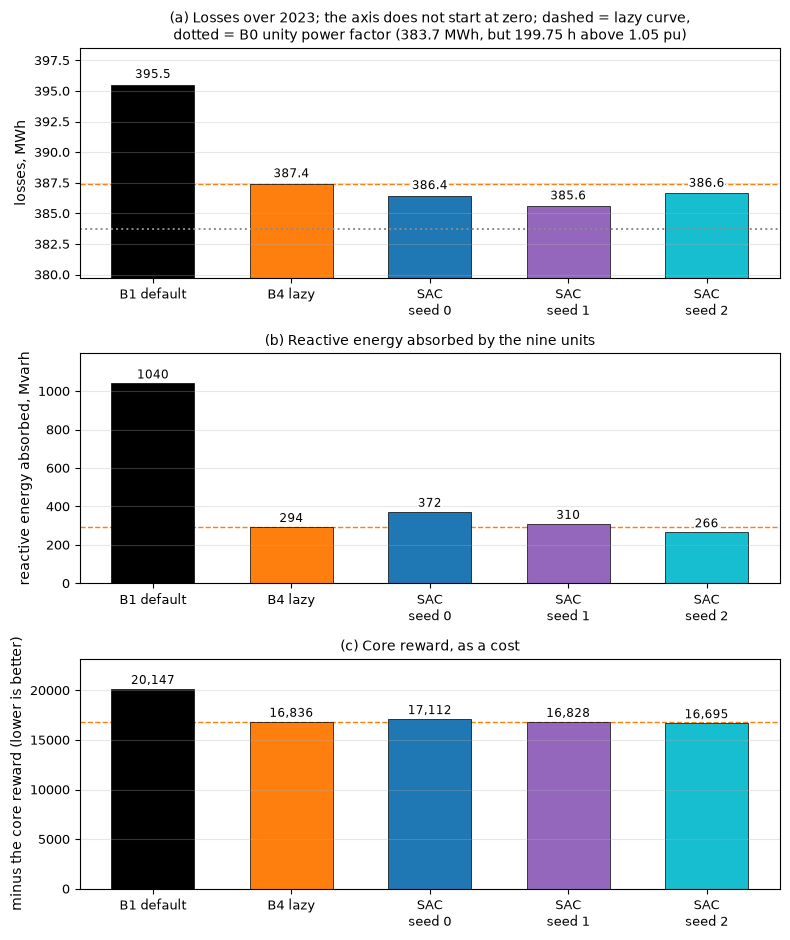

In [13]:
COLS8 = ["hours_viol", "vpi_puh", "losses_MWh", "curtailed_MWh", "Q_abs_Mvarh", "Q_inj_Mvarh", "fence_steps", "fence_kvarh", "core_reward"]
def results_table(mask=None, extra_rows=()):
    rows = {NAMES[n]: row(runs[n], mask) for n in ("unity", "default", "tight", "lazy")}
    for n in extra_rows:
        rows[NAMES[n]] = row(runs[n], mask)
    df_b = pd.DataFrame({s: row(sac[s]["best_run"], mask) for s in SEEDS}).T
    for s in SEEDS:
        rows[f"SAC seed {s} (episode {sac[s]['best_episode']})"] = df_b.loc[s].to_dict()
    rows["SAC mean of 3 seeds"] = df_b.mean().to_dict(); rows["SAC minimum"] = df_b.min().to_dict(); rows["SAC maximum"] = df_b.max().to_dict()
    return pd.DataFrame(rows).T[COLS8], df_b
tab_year, df_best = results_table()
print(f"full year {YEAR} ({T:,} steps); SAC = kept checkpoint of each seed, deterministic policy, fence on:"); show(tab_year)
df_final = pd.DataFrame({s: row(sac[s]["final_run"]) for s in SEEDS}).T
tab_final = df_final.copy(); tab_final.index = [f"SAC seed {s}, end of training" for s in SEEDS]
print("\npolicies at the end of training, for comparison:"); show(tab_final[COLS8])

lazy_row = row(runs["lazy"]); def_row = row(runs["default"])
print("\nkept checkpoints against the lazy curve, full year (mean [min, max] over three seeds):")
verdict = {}
for c, better in (("core_reward", "higher"), ("losses_MWh", "lower"), ("Q_abs_Mvarh", "lower")):
    lo, hi, m = df_best[c].min(), df_best[c].max(), df_best[c].mean()
    wins = (lo > lazy_row[c]) if better == "higher" else (hi < lazy_row[c])
    loses = (hi < lazy_row[c]) if better == "higher" else (lo > lazy_row[c])
    verdict[c] = "better than the lazy curve in every seed" if wins else ("worse than the lazy curve in every seed" if loses else "not resolved over three seeds (the seed range contains the lazy value)")
    print(f"  {c:12s} SAC {m:10,.1f} [{lo:10,.1f}, {hi:10,.1f}]   lazy {lazy_row[c]:10,.1f}   default {def_row[c]:10,.1f}   -> {verdict[c]}")
print(f"  against the default curve: losses {100 * (df_best.losses_MWh.mean() / def_row['losses_MWh'] - 1):+.1f} %, absorbed reactive energy "
      f"{100 * (df_best.Q_abs_Mvarh.mean() / def_row['Q_abs_Mvarh'] - 1):+.0f} % (range {100 * (df_best.Q_abs_Mvarh.min() / def_row['Q_abs_Mvarh'] - 1):+.0f} to "
      f"{100 * (df_best.Q_abs_Mvarh.max() / def_row['Q_abs_Mvarh'] - 1):+.0f} %), core reward {df_best.core_reward.mean() - def_row['core_reward']:+,.0f}")
print(f"  fence, kept checkpoints: {df_best.fence_steps.min():.0f} to {df_best.fence_steps.max():.0f} steps of {T:,} ({100 * df_best.fence_steps.max() / T:.2f} % at most), "
      f"{df_best.fence_kvarh.min() / 1e3:.1f} to {df_best.fence_kvarh.max() / 1e3:.1f} Mvarh added ({100 * (df_best.fence_kvarh / 1e3 / df_best.Q_abs_Mvarh).min():.1f} to "
      f"{100 * (df_best.fence_kvarh / 1e3 / df_best.Q_abs_Mvarh).max():.1f} % of the absorbed energy), curtailed by the fence "
      + ", ".join(f"{sac[s]['best_run'].extra['safety_dp'].sum() * DT_H:.1f}" for s in SEEDS) + " kWh; largest voltage before the fence "
      + ", ".join(f"{sac[s]['best_run'].extra['v_before'].max():.4f}" for s in SEEDS) + " pu")

print("\nwhere the curtailed energy comes from (kept | end-of-training checkpoint): unit-steps on which the delivered |Q| exceeds the 0.44 clamp, and the fence's own curtailment:")
for s in SEEDS:
    parts = []
    for r in (sac[s]["best_run"], sac[s]["final_run"]):
        qpu = r.q_kvar / PV_KVA; curt = np.maximum(0.0, r.p_avail_kw - r.p_kw); big = curt.sum(axis=1) > 1.0
        parts.append(f"{int((qpu < -0.445).sum())} unit-steps (largest |Q| {-qpu.min():.2f} pu of kVA), curtailed {curt.sum() * DT_H:.1f} kWh on {int(big.sum())} steps "
                     f"(units {sorted({PV_BUSES[j] for j in curt[big].argmax(axis=1)}) if big.any() else []}, fence active on {int(r.extra['safety_active'][big].sum())} of them), "
                     f"fence curtailment {r.extra['safety_dp'].sum() * DT_H:.1f} kWh")
    print(f"  seed {s}: " + " | ".join(parts))

labels = ["B1 default", "B4 lazy"] + [f"SAC\nseed {s}" for s in SEEDS]
colors = [COL["default"], COL["lazy"]] + [SEED_COL[s] for s in SEEDS]
fig, axes = plt.subplots(3, 1, figsize=(8, 9.5))
for ax, (c, lab, fmt_) in zip(axes, (("losses_MWh", "losses, MWh", "{:.1f}"), ("Q_abs_Mvarh", "reactive energy absorbed, Mvarh", "{:.0f}"),
                                     ("core_reward", "minus the core reward (lower is better)", "{:,.0f}"))):
    vals = np.array([abs(def_row[c]), abs(lazy_row[c])] + [abs(df_best.loc[s, c]) for s in SEEDS])
    ax.bar(range(5), vals, 0.6, color=colors, edgecolor="black", lw=0.5)
    ax.axhline(abs(lazy_row[c]), color=COL["lazy"], lw=1, ls="--", zorder=0)
    if c == "losses_MWh":
        u = row(runs["unity"])["losses_MWh"]; ax.set_ylim(u - 4, vals.max() + 3)
        ax.axhline(u, color=COL["unity"], lw=1.4, ls=":")
        off = 0.3
    else:
        ax.set_ylim(0, vals.max() * 1.15); off = 0.01 * vals.max()
    for xi, v in enumerate(vals):
        ax.text(xi, v + off, fmt_.format(v), ha="center", va="bottom", fontsize=8.5, bbox=dict(fc="white", ec="none", pad=0.6))
    ax.set_xticks(range(5)); ax.set_xticklabels(labels); ax.set_ylabel(lab); ax.grid(axis="y", alpha=0.3)
u_row = row(runs["unity"])
axes[0].set_title(f"(a) Losses over {YEAR}; the axis does not start at zero; dashed = lazy curve,\ndotted = B0 unity power factor ({u_row['losses_MWh']:.1f} MWh, but {u_row['hours_viol']:.2f} h above 1.05 pu)")
axes[1].set_title("(b) Reactive energy absorbed by the nine units"); axes[2].set_title("(c) Core reward, as a cost")
plt.tight_layout(); plt.show()

**Against the default curve.** All three kept checkpoints leave zero hours outside the
band over the full year. Their losses are 385.6 to 386.6 MWh (mean 386.2) against 395.5 MWh,
2.3 % lower; they absorb 266 to 372 Mvarh (mean 316) against 1,040 Mvarh, 64 to 74 % less;
the core reward is -17,112 to -16,695 (mean -16,878) against -20,147. On every quantity the
whole seed range lies on the better side of the default curve.

**Against the lazy curve.** The single hand-set curve B4 scores -16,836 with 387.4 MWh and
294 Mvarh. In core reward two seeds are better (by 8 and 141) and one is worse (by 276); in
absorbed reactive energy one seed is below and two are above: both comparisons are **not
resolved over three seeds**, the seed range contains the lazy value. Only the losses are
lower than those of the lazy curve in every seed, by 0.8 to 1.8 MWh (0.2 to 0.5 %). The
policies at the end of training are worse than the lazy curve on core reward in every seed
(-18,258, -17,055, -17,034); only the selected checkpoints are level with it, with the
selection caveat of step 5.

**The fence** acted on 36, 130 and 79 of the 35,040 steps (at most 0.37 %) and added 1.3 to
4.2 Mvarh, 0.4 to 1.3 % of the absorbed energy; the largest voltage it had to correct was
1.0608 pu. It never used its active-power stage (0.0 kWh).

**A side observation.** Seed 2 shows 4.8 kWh of curtailed energy in the year (155 kWh for
its end-of-training policy) although the fence curtailed nothing. The diagnostic lines
under the tables locate it: on a handful of unit-steps, without the fence being active, the
reactive power delivered by a unit exceeds the 0.44 pu clamp of the curve family (up to
0.55 pu of kVA for the kept checkpoint, 0.69 for the end-of-training policy), the inverter
reaches its kVA rating and OpenDSS trims the active power. It happens at bus 11 under the
nearly vertical curves noted in step 6 (the single such unit-step of seed 0 is different:
there the fence was active, and the fence may use the full capability of the inverter). The amounts are negligible in the KPIs (the reward
charges them at 0.05 per kW), but the delivered Q should not exceed the clamp; the cause
lies in the interaction of the InvControl iteration with a very steep curve and was not
examined here. It is carried to notebook 07 as an open item; a larger minimum gap between
V3 and V4 would be the obvious remedy.

## 9. Results on the sampled days, with the OPF

The OPF of step 3 exists only on the 32 sampled days, so the comparison that includes it
is made on those days: the same table as in step 8, restricted to the 3,072 sampled steps,
with the two OPF rows added. The figure then expresses each controller as the share of the
gap between the default curve (0) and the reward-objective OPF (1) that it closes, in
losses, absorbed reactive energy and core reward; the bar of the learned policies is the
mean of the three seeds and the markers are the single seeds.

the 32 sampled days (3,072 steps):
                               hours_viol vpi_puh losses_MWh curtailed_MWh Q_abs_Mvarh Q_inj_Mvarh fence_steps fence_kvarh core_reward
B0 unity pf                         24.75  0.5208      32.83        0.0000         0.0         0.0           0           0      -3,397
B1 default curve                     0.00  0.0000      33.94        0.0000        97.1         3.6           0           0      -1,761
B3 tight curve                       0.00  0.0000      39.16        0.0000       389.3         3.6           0           0      -3,138
B4 lazy curve                        0.00  0.0000      33.20        0.0000        28.7         3.6           0           0      -1,457
B5 OPF, loss objective (nb 04)       0.00  0.0000      31.72        0.0000         5.1        88.9           0           0      -1,645
OPF, reward objective                0.25  0.0000      32.90        0.0141         4.5         0.4           0           0      -1,338
SAC seed 0 (episode 

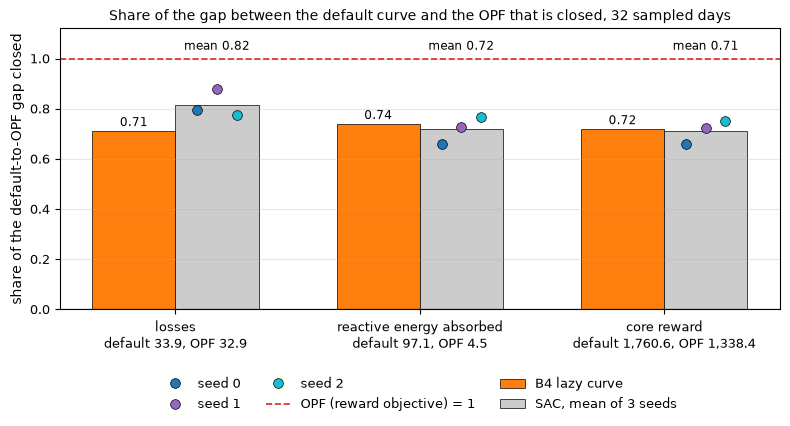

               losses  reactive energy absorbed  core reward
B4 lazy curve    0.71                      0.74         0.72
SAC seed 0       0.79                      0.66         0.66
SAC seed 1       0.88                      0.73         0.72
SAC seed 2       0.78                      0.77         0.75
SAC mean         0.82                      0.72         0.71

core reward on the sampled days: OPF -1,338, SAC -1,483 to -1,444 (mean -1,461), lazy -1,457, default -1,761; remaining gap of the SAC mean to the OPF 122 (29 % of the default-to-OPF gap), of which losses 8 and reactive power 117


In [14]:
tab_sample, df_best_s = results_table(mask_sample, extra_rows=("B5", "opf"))
print(f"the {len(SAMPLE_DAYS)} sampled days ({len(steps_sample):,} steps):"); show(tab_sample)

GAP = [("losses_MWh", "losses"), ("Q_abs_Mvarh", "reactive energy absorbed"), ("core_reward", "core reward")]
d_s, l_s, o_s = (row(runs[n], mask_sample) for n in ("default", "lazy", "opf"))
closed = lambda k, c: (d_s[c] - k[c]) / (d_s[c] - o_s[c])
gap_lazy = [closed(l_s, c) for c, _ in GAP]
gap_sac = np.array([[closed(df_best_s.loc[s], c) for c, _ in GAP] for s in SEEDS])
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(GAP)); w = 0.34
ax.bar(x - w / 2, gap_lazy, w, color=COL["lazy"], edgecolor="black", lw=0.5, label="B4 lazy curve")
ax.bar(x + w / 2, gap_sac.mean(axis=0), w, color="0.8", edgecolor="black", lw=0.5, label="SAC, mean of 3 seeds")
for i, s in enumerate(SEEDS):
    ax.plot(x + w / 2 + (i - 1) * 0.08, gap_sac[i], "o", color=SEED_COL[s], ms=7, mec="black", mew=0.5, label=f"seed {s}", zorder=5)
for xi, v in zip(x - w / 2, gap_lazy):
    ax.text(xi, v + 0.02, f"{v:.2f}", ha="center", fontsize=8.5)
for xi, v in zip(x + w / 2, gap_sac.mean(axis=0)):
    ax.text(xi, 1.035, f"mean {v:.2f}", ha="center", fontsize=8.5)
ax.axhline(1.0, color=COL["opf"], lw=1.2, ls="--", label="OPF (reward objective) = 1"); ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f"{lab}\ndefault {abs(d_s[c]):,.1f}, OPF {abs(o_s[c]):,.1f}" for c, lab in GAP])
ax.set_ylim(0, 1.12); ax.set_ylabel("share of the default-to-OPF gap closed"); ax.grid(axis="y", alpha=0.3)
ax.set_title(f"Share of the gap between the default curve and the OPF that is closed, {len(SAMPLE_DAYS)} sampled days")
legend_below(ax, ncol=3, dy=-0.2)
plt.tight_layout(); plt.show()
gap_tab = pd.DataFrame({"B4 lazy curve": gap_lazy, **{f"SAC seed {s}": gap_sac[i] for i, s in enumerate(SEEDS)}, "SAC mean": gap_sac.mean(axis=0)}, index=[lab for _, lab in GAP]).T
print(gap_tab.to_string(float_format=lambda v: f"{v:.2f}"))
print(f"\ncore reward on the sampled days: OPF {o_s['core_reward']:,.0f}, SAC {df_best_s.core_reward.min():,.0f} to {df_best_s.core_reward.max():,.0f} (mean {df_best_s.core_reward.mean():,.0f}), "
      f"lazy {l_s['core_reward']:,.0f}, default {d_s['core_reward']:,.0f}; remaining gap of the SAC mean to the OPF {o_s['core_reward'] - df_best_s.core_reward.mean():,.0f} "
      f"({100 * (1 - gap_sac.mean(axis=0)[2]):.0f} % of the default-to-OPF gap), of which losses {CFG.w_loss * 1e3 / DT_H * (df_best_s.losses_MWh.mean() - o_s['losses_MWh']):,.0f} "
      f"and reactive power {CFG.w_q * 1e3 / DT_H * ((df_best_s.Q_abs_Mvarh.mean() + df_best_s.Q_inj_Mvarh.mean()) - (o_s['Q_abs_Mvarh'] + o_s['Q_inj_Mvarh'])):,.0f}")

On the sampled days the kept checkpoints score -1,483, -1,455 and -1,444 (mean -1,461),
the lazy curve -1,457, the default curve -1,761 and the OPF -1,338. Of the gap between the
default curve and the OPF the learned policies close 78 to 88 % in losses (lazy curve 71 %),
66 to 77 % in absorbed reactive energy (74 %) and 66 to 75 % in core reward (72 %). As on
the full year, the policies are ahead of the lazy curve in losses in every seed and level
with it, within the seed range, in the other two.

About 29 % of the gap remains (122 reward units for the mean of the seeds), and almost all
of it is reactive power: 117 units against 8 for the losses. The learned policies absorb 26
to 36 Mvarh on these days, the OPF 4.5 Mvarh. The OPF absorbs on 98 of 3,072 steps, only
when a bus would otherwise pass 1.05 pu, and then almost only at the two or three units
whose reactive power moves that bus most. A local curve absorbs whenever its own terminal
voltage is above V3, which on a sunny day is true for hours at all nine units, most of them
hours in which no bus is near the limit. To do what the OPF does, a unit would have to know
whether some bus of the feeder is at the limit right now, and where it sits relative to
that bus. Its own voltage says little about either: at the noon of the worst day the nine
PV-bus voltages lie within a band of a few thousandths of a pu (the grey band of step 6),
and the sensitivity matrix of notebook 05 showed that the far end is only about 1.3 times
more effective than the head of the feeder. The unit ID could in principle carry the
position, but whether the limit binds elsewhere is not observable from one bus. This part of
the gap is therefore a limit of local observation, not of the training budget.

## 10. Save

`models/sac_seed<k>_best.pt` and `models/sac_seed<k>_final.pt` hold the actor, the critics,
the temperature and the configuration of each seed (format of `agents.SACAgent.save`;
`SACAgent().load(path)` restores them). `train_2023.h5` holds one group per seed with the
per-episode log (reward with and without the fence charge, temperature, losses of critic
and actor, entropy, fence interventions and amounts, day index, time), the evaluation
table (episode, core reward, KPIs on the year and on the sampled days, fence statistics),
and the full-year runs of the kept and of the last checkpoint (voltages after and before
the fence, P, Q, irradiance, losses, the reward, the core reward and the five terms, the
fence flags and amounts, the curves applied, the KPIs as attributes); plus the OPF run of
step 3 with its log. `train_summary.json` holds the configuration, the training pool, the
timings, the tables of steps 3, 8 and 9, the gap shares, the evaluation logs and the
position correlations.

In [15]:
T_NB = time.perf_counter() - T_NB0
def save_run(g, r):
    g.create_dataset("steps", data=r.steps); g.create_dataset("time", data=(r.index.asi8 // 10 ** 9).astype(np.int64))
    for k in ("v", "p_kw", "q_kvar", "irr", "losses_kw"):
        g.create_dataset(k, data=getattr(r, k).astype(np.float32), compression="gzip")
    g.create_dataset("failed", data=r.failed)
    e = getattr(r, "extra", None) or {}
    if "reward" in e:
        for k in ("reward", "reward_core", "term_viol", "term_loss", "term_q", "term_curt", "term_safety", "safety_dq", "safety_dp", "v_before", "curves"):
            g.create_dataset(k, data=np.asarray(e[k]).astype(np.float32), compression="gzip")
        g.create_dataset("safety_active", data=e["safety_active"]); g.create_dataset("safety_solves", data=e["safety_solves"])
        g.attrs["config"] = json.dumps(e["config"])
    g.attrs["label"] = r.label; g.attrs["runtime_s"] = r.runtime_s
    for k, v in kpi.kpis_of(r).items():
        g.attrs["kpi_" + k] = v
    g.attrs["core_reward"] = float(core_reward_steps(r).sum())

with h5py.File("train_2023.h5", "w") as f:
    f.attrs["year"] = attrs["year"]; f.attrs["dt_h"] = DT_H; f.attrs["pv_buses"] = PV_BUSES; f.attrs["f1_buses"] = F1
    f.attrs["sample_days"] = SAMPLE_DAYS; f.attrs["train_days"] = train_days; f.attrs["sac_config"] = json.dumps(SAC_CFG.to_dict())
    f.attrs["env_config"] = json.dumps(envcfg["env"]); f.attrs["n_episodes"] = N_EPISODES; f.attrs["eval_every"] = EVAL_EVERY
    f.attrs["warmup"] = WARMUP; f.attrs["torch_threads"] = N_THREADS; f.attrs["distance_km"] = DIST_KM
    for s, v in sac.items():
        g = f.create_group(f"seed{s}")
        g.create_dataset("episodes", data=pd.DataFrame(v["log"]["episodes"]).to_records(index=False))
        g.create_dataset("evals", data=pd.DataFrame(v["log"]["evals"]).to_records(index=False))
        g.attrs["train_time_s"] = v["log"]["train_time_s"] - v["log"]["eval_time_s"]; g.attrs["eval_time_s"] = v["log"]["eval_time_s"]
        g.attrs["total_time_s"] = v["log"]["total_time_s"]; g.attrs["steps_total"] = v["log"]["steps_total"]
        g.attrs["best_episode"] = v["best_episode"]; g.attrs["best_model"] = v["best_path"]; g.attrs["final_model"] = v["final_path"]
        save_run(g.create_group("best_run"), v["best_run"]); save_run(g.create_group("final_run"), v["final_run"])
    g = f.create_group("opf_reward"); save_run(g, runs["opf"])
    g.create_dataset("opf_log", data=opf_log.drop(columns=["method", "chosen"]).to_records(index=False))

timing = {f"seed{s}": dict(train_s=v["log"]["train_time_s"] - v["log"]["eval_time_s"], eval_s=v["log"]["eval_time_s"], total_s=v["log"]["total_time_s"],
                           steps=v["log"]["steps_total"], updates=v["agent"].n_updates) for s, v in sac.items()}
summary = dict(sac_config=SAC_CFG.to_dict(), env_config=envcfg["env"], torch_version=torch.__version__, torch_threads=N_THREADS,
               n_episodes=N_EPISODES, eval_every=EVAL_EVERY, warmup=WARMUP, seeds=list(SEEDS),
               training_pool=dict(n_days=N_TRAIN_DAYS, seed=0, peak_threshold=0.5, weight_sunny=3.0, days=[int(d) for d in train_days]),
               training_reward="environment reward including the fence charge", selection_reward="full-year core reward (without the fence charge)",
               best_episode={f"seed{s}": v["best_episode"] for s, v in sac.items()},
               models={f"seed{s}": dict(best=v["best_path"], final=v["final_path"]) for s, v in sac.items()},
               opf=dict(objective="reward", weights=dict(viol=CFG.w_viol, loss=CFG.w_loss, q=CFG.w_q, curt=CFG.w_curt), curtail=True, capability=True,
                        q_max_pu_kva=0.44, time_per_step_ms=float(opf_log.time_s.mean() * 1e3), sample_days=SAMPLE_DAYS),
               reference_core_reward_full_year=REF, timing_s=timing, notebook_runtime_s=T_NB,
               tables=dict(opf_sampled_days=tab3.to_dict(orient="index"), full_year=tab_year.to_dict(orient="index"),
                           full_year_end_of_training=tab_final.to_dict(orient="index"), sampled_days=tab_sample.to_dict(orient="index"),
                           gap_closed=gap_tab.to_dict(orient="index")),
               verdict_against_lazy=verdict, evals={f"seed{s}": v["log"]["evals"] for s, v in sac.items()},
               position=dict(distance_km={str(b): float(x) for b, x in zip(PV_BUSES, DIST_KM)}, spearman=pos_tab.reset_index().to_dict(orient="records"),
                             per_unit={f"seed{s}": {k: np.asarray(v).tolist() for k, v in pos[s].items()} for s in SEEDS}))
with open("train_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
with h5py.File("train_2023.h5", "r") as f:
    print("train_2023.h5:", ", ".join(f"{k}/{list(f[k].keys())}" for k in f))
print(f"train_2023.h5 {os.path.getsize('train_2023.h5') / 1e6:.1f} MB, train_summary.json {os.path.getsize('train_summary.json') / 1e3:.0f} kB")
print("models:", sorted(os.listdir("models")))
print("runtime: " + "; ".join(f"{k}: training {t['train_s']:.0f} s + evaluations {t['eval_s']:.0f} s = {t['total_s']:.0f} s" for k, t in timing.items()))
print(f"whole notebook up to this cell: {T_NB / 60:.1f} min")

train_2023.h5: opf_reward/['failed', 'irr', 'losses_kw', 'opf_log', 'p_kw', 'q_kvar', 'steps', 'time', 'v'], seed0/['best_run', 'episodes', 'evals', 'final_run'], seed1/['best_run', 'episodes', 'evals', 'final_run'], seed2/['best_run', 'episodes', 'evals', 'final_run']
train_2023.h5 58.6 MB, train_summary.json 75 kB
models: ['sac_seed0_best.pt', 'sac_seed0_final.pt', 'sac_seed1_best.pt', 'sac_seed1_final.pt', 'sac_seed2_best.pt', 'sac_seed2_final.pt']
runtime: seed0: training 285 s + evaluations 275 s = 560 s; seed1: training 303 s + evaluations 283 s = 586 s; seed2: training 326 s + evaluations 291 s = 617 s
whole notebook up to this cell: 30.0 min


## 11. Closing

- **What the agents learned.** A soft actor-critic with one actor shared by the nine units,
  trained for 500 single-day episodes per seed on 120 days of the year, learns volt-var
  curves that are milder than the IEEE 1547 Category B default: they start absorbing at
  about the same voltage (mean V3 1.019 to 1.024 pu against 1.02) but with a much flatter
  slope, 0.05 to 0.07 pu of kVA at 1.05 pu where the default asks for 0.22 and the lazy curve
  for 0.126, and they change over the day. With the
  fence on, the kept checkpoints leave zero violation hours in the full year, with losses of
  385.6 to 386.6 MWh against 395.5 MWh (2.3 % lower on average) and 266 to 372 Mvarh absorbed
  against 1,040 Mvarh (64 to 74 % less); the core reward is -17,112 to -16,695 against
  -20,147. On these three quantities every seed is better than the default curve.
- **Against the hand-set lazy curve.** B4 scores -16,836 with 387.4 MWh and 294 Mvarh. The
  learned policies have lower losses in every seed (by 0.2 to 0.5 %), but in core reward and
  in absorbed reactive energy the comparison is not resolved over three seeds: the seed
  ranges contain the lazy value. The same holds on the sampled days (-1,483 to -1,444
  against -1,457). A learned local policy is as good as one well-chosen fixed curve here, and
  not demonstrably better. The kept checkpoints are selected on the evaluation year itself,
  which favours them slightly; the policies at the end of training are 227 to 1,146 worse
  and below the lazy curve.
- **Position.** No position pattern that is consistent across seeds appeared. At the
  worst-day noon the rank correlation of Q4 with the distance from the substation is -0.77,
  +0.08 and +0.07, and the seeds do not agree with each other (mean pairwise correlation
  -0.07); over the year all correlations are negative but weak and not significant. The OPF
  concentrates its absorption at the far ends (93 % at buses 7, 10 and 11); the agents do not.
- **The fence.** During training it kept every step inside the band while the policy
  explored, acting on about 0.2 steps per episode at the end, and the charge on it (2 to 3 %
  of a day's reward) was enough to bring its use in the evaluated year down after an initial
  rise. For the kept checkpoints it acts on 36 to 130 steps of the year (at most 0.37 %) and
  adds 1.3 to 4.2 Mvarh, about 1 % of the absorbed energy, without curtailing. The zero
  violation hours of the learned policies are therefore a joint result of curve and fence;
  the fixed default and lazy curves need no fence at this PV size.
- **The remaining gap to the OPF.** On the sampled days the policies close 66 to 75 % of the
  default-to-OPF gap in core reward (lazy curve 72 %). What remains is reactive power: 26 to
  36 Mvarh against 4.5 Mvarh. The OPF absorbs only on the steps where a bus would pass the
  limit and only at the units that move that bus most; its allocation depends on where a
  unit sits relative to the binding bus and on whether any bus binds at all, and a unit
  cannot infer either from its own voltage alone. Local observation cannot close this part
  of the gap, however long the training.
- **Open items.** The full-year evaluation is not monotonic in training, which points to the
  size of the training pool and to the absence of a held-out selection year; the event part
  of the fence charge may be what keeps the critic loss near 1.5; on a few unit-steps a
  nearly vertical learned curve delivered more reactive power than its clamp allows (step
  8); three seeds are too few to separate the learned policies from the lazy curve.
- **Runtime.** 9.3 to 10.3 minutes per seed on a CPU with two torch threads (about 5
  minutes of training for 48,000 steps and updates, 4.6 to 4.9 minutes for the eleven
  full-year evaluations), under half a minute for the OPF on the sampled days, 30 minutes
  for the whole notebook.

Notebook 07 brings the baselines of notebook 04, the environment checks of notebook 05 and
the policies trained here together in one comparison on the full year and on the sampled
days, and takes up the open items listed above.

Files: `agents.py` (`SACConfig`, `SACAgent`, `train_sac`, `sac_policy`, `unit_obs`,
`sample_training_days`, `save_snapshot`), `models/sac_seed{0,1,2}_{best,final}.pt`,
`train_2023.h5`, `train_summary.json` and this notebook. `cigre_dss.py`, `profiles.py`,
`simulate.py`, `kpi.py` and `env.py` are unchanged.